# Figure 3h-i - Prediction of EEG from facial features

This notebook contains the code to reproduce Fig3h-i. To run this code, you need the following Anipose projects:
- `202408-eeg-emg-all`
- `202505-eeg-redose`

as well as corresponding EEG data for each recording in the Anipose project.

In [7]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys

pwd = %pwd
if pwd.endswith('notebooks'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define the recording start times relative to injection (as well as redose injection time).

In [8]:
ANES_START = {
    ("20240822", "B47"): 4 * 60 + 22,
    ("20240822", "B48"): 3 * 60 + 50,
    ("20240912", "B47"): 4 * 60 + 17,
    ("20240912", "B48"): 4 * 60 + 17,
    ("20240913", "B47"): 6 * 60 + 30, #anes video only
    ("20240913", "B48"): 3 * 60 + 33, #anes video only
    ("20240917", "B47"): 4 * 60 + 40,
    ("20240917", "B48"): 4 * 60 + 3,
    ("20240918", "B47"): 3 * 60 + 20,
    ("20240918", "B48"): 3 * 60 + 45,
    ("20240924", "B53"): 3 * 60 + 5,  #anes video only
    ("20240925", "B53"): 5 * 60 + 56,
    ("20240926", "B53"): 4 * 60 + 3,  #anes video only
    ("20240927", "B53"): 3 * 60 + 0,  #anes video only
    ("20250522", "B72"): 4 * 60 + 10,
    ("20250522", "B73"): 4 * 60 + 20,
    ("20250522", "B74"): 5 * 60 + 1,
    ("20250522", "B75"): 4 * 60 + 9,
    ("20250523", "B72"): 4 * 60 + 0,
    ("20250523", "B73"): 3 * 60 + 44,
    ("20250523", "B74"): 3 * 60 + 27,
    ("20250523", "B75"): 4 * 60 + 4,
    ("20250527", "B72"): 3 * 60 + 29,
    ("20250527", "B73"): 3 * 60 + 0,
    ("20250527", "B74"): 3 * 60 + 4,
    ("20250527", "B75"): 4 * 60 + 10,
    ("20250528", "B72"): 6 * 60 + 20,
    ("20250528", "B74"): 3 * 60 + 40,
    ("20250528", "B75"): 5 * 60 + 57,
    ("20250617", "B72"): 4 * 60 + 5,
    ("20250617", "B74"): 3 * 60 + 48,
    ("20250617", "B75"): 4 * 60 + 38,
    ("20250618", "B72"): 3 * 60 + 38,
    ("20250618", "B74"): 3 * 60 + 31,
    ("20250618", "B75"): 5 * 60 + 10,
}

REDOSE = {
    ("20240822", "B47"): None,
    ("20240822", "B48"): None,
    ("20240912", "B47"): None,
    ("20240912", "B48"): None,
    ("20240913", "B47"): None,
    ("20240913", "B48"): None,
    ("20240917", "B47"): None,
    ("20240917", "B48"): None,
    ("20240918", "B47"): None,
    ("20240918", "B48"): None,
    ("20240924", "B53"): None,
    ("20240925", "B53"): None,
    ("20240926", "B53"): None,
    ("20240927", "B53"): None,
    ("20250522", "B72"): 30 * 60 + 0,
    ("20250522", "B73"): 31 * 60 + 0,
    ("20250522", "B74"): 30 * 60 + 0,
    ("20250522", "B75"): 30 * 60 + 0,
    ("20250523", "B72"): 30 * 60 + 0,
    ("20250523", "B73"): 30 * 60 + 0,
    ("20250523", "B74"): 30 * 60 + 0,
    ("20250523", "B75"): 30 * 60 + 0,
    ("20250527", "B72"): 38 * 60 + 30,
    ("20250527", "B73"): 39 * 60 + 0,
    ("20250527", "B74"): 39 * 60 + 0,
    ("20250527", "B75"): 38 * 60 + 0,
    ("20250528", "B72"): 30 * 60 + 0,
    ("20250528", "B74"): 30 * 60 + 0,
    ("20250528", "B75"): 27 * 60 + 0,
    ("20250617", "B72"): 30 * 60 + 0,
    ("20250617", "B74"): 30 * 60 + 0,
    ("20250617", "B75"): 30 * 60 + 0,
    ("20250618", "B72"): 30 * 60 + 0,
    ("20250618", "B74"): 30 * 60 + 0,
    ("20250618", "B75"): 30 * 60 + 0,
}

In [9]:
# set to None for CPU, or set to GPU ID
GPU = None

os.environ["CUDA_VISIBLE_DEVICES"] = "" if GPU is None else str(GPU)
import jax

jax.devices()

[CpuDevice(id=0)]

In [10]:
import json
import itertools
import optax
import pandas as pd
import numpy as np
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from tqdm.auto import tqdm
from pqdm.processes import pqdm
from glob import glob
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from scipy.signal import iirdesign, sosfilt, spectrogram
from functools import partial
from fractions import Fraction
from typing import Optional, Union, Tuple
from jaxtyping import Array, Float, Scalar
from dynamax.linear_gaussian_ssm import LinearGaussianSSM
from dynamax.utils.utils import psd_solve
from dynamax.types import PRNGKeyT
from dynamax.linear_gaussian_ssm.models import SuffStatsLGSSM
from dynamax.linear_gaussian_ssm.inference import (ParamsLGSSM,
                                                   PosteriorGSSMFiltered,
                                                   PosteriorGSSMSmoothed,
                                                   _get_params,
                                                   _condition_on,
                                                   _predict,
                                                   preprocess_args,
                                                   preprocess_params_and_inputs)

from tensorflow_probability.substrates.jax.distributions import (
    MultivariateNormalDiagPlusLowRankCovariance as MVNLowRank,
    MultivariateNormalFullCovariance as MVN)

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df

from labutils.plotting import (sns_setup,
                               landmark_cmap,
                               measurements_cmap,
                               save_figure)
from labutils.utils import maybe, flat_list

sns_setup(palette="colorblind", font="sans-serif")
OUTPUT_DIR = "./figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

_, LANDMARK_CMAP = landmark_cmap()
_, MEASUREMENT_CMAP = measurements_cmap()

CACHE = "measurements-data-cache"
MODEL_CACHE = Path(CACHE) / "eeg-models"

CONTROL_CMAP = sns.color_palette([sns.color_palette("colorblind")[2],
                                  sns.color_palette("colorblind")[-3],
                                  sns.color_palette("colorblind")[3]])

ANIPOSE_PATHS = {"original": "anipose-projects/202408-eeg-emg-all",
                 "redose": "anipose-projects/202505-eeg-redose"}
COORDINATE_PATHS = {}
key_cols = ("date", "mouse", "cond", "run")
for location, p in sorted((location, p)
                          for location, path in ANIPOSE_PATHS.items()
                          for p in Path(path).glob('*/pose-3d/*.csv')):
    date, mouse, *_, cond, run, _ = p.name.split("_")
    if cond == "awake":
        continue
    if mouse == "B73" and date == "20250527":
        continue
    if date == "20240816" or date == "20240822" or date == "20250508" or date == "20250509":
        continue
    COORDINATE_PATHS[(date, mouse, cond, run)] = p
data_keys = list(COORDINATE_PATHS.keys())
data_keys

[('20240912', 'B47', 'anes', '000'),
 ('20240912', 'B48', 'anes', '000'),
 ('20240913', 'B47', 'anes', '000'),
 ('20240913', 'B48', 'anes', '000'),
 ('20240917', 'B47', 'anes', '000'),
 ('20240917', 'B48', 'anes', '000'),
 ('20240918', 'B47', 'anes', '000'),
 ('20240918', 'B48', 'anes', '000'),
 ('20240924', 'B53', 'anes', '000'),
 ('20240925', 'B53', 'anes', '000'),
 ('20240926', 'B53', 'anes', '000'),
 ('20240927', 'B53', 'anes', '000'),
 ('20250522', 'B72', 'anes', '000'),
 ('20250522', 'B73', 'anes', '000'),
 ('20250522', 'B74', 'anes', '000'),
 ('20250522', 'B75', 'anes', '000'),
 ('20250523', 'B72', 'anes', '000'),
 ('20250523', 'B73', 'anes', '000'),
 ('20250523', 'B74', 'anes', '000'),
 ('20250523', 'B75', 'anes', '000'),
 ('20250527', 'B72', 'anes', '000'),
 ('20250527', 'B74', 'anes', '000'),
 ('20250527', 'B75', 'anes', '000'),
 ('20250528', 'B72', 'anes', '000'),
 ('20250528', 'B74', 'anes', '000'),
 ('20250528', 'B75', 'anes', '000'),
 ('20250617', 'B72', 'anes', '000'),
 

## Load datasets

### Behavior

In [5]:
coord_data = {k: read_3d_data(v.parent.parent.as_posix(),
                              extra_cols=["ncams", "score"])
              for k, v in COORDINATE_PATHS.items()}

meas_df = compute_measurements_df({k: v[0] for k, v in coord_data.items()},
                                  key_columns=key_cols)
meas_df.head()

,date,mouse,cond,run,measurement_group,measurement_name,measurement_units,measurement_type,measurement_value,std,count,timeseries
0,20240912,B47,anes,000,eye,eye-height-left,mm,distance,2.632703,0.029324,376049,"[2.527965605390745, 2.5277071825544417, 2.5274..."
78,20240917,B47,anes,000,ear,ear-angle-left,deg,angle,167.777502,0.693054,390738,"[168.00979344649463, 167.9943100137546, 167.98..."
77,20240917,B47,anes,000,ear,ear-width-right,mm,distance,6.239100,0.104708,390738,"[6.301608909863193, 6.3007392013456505, 6.2999..."
76,20240917,B47,anes,000,ear,ear-width-left,mm,distance,6.716015,0.124379,390738,"[6.6347009787378175, 6.634992885965099, 6.6348..."
75,20240917,B47,anes,000,ear,ear-height-right,mm,distance,12.261022,0.254212,390738,"[12.418900259925511, 12.415227602365036, 12.41..."


In [6]:
# add sample rate, etc.
meas_df["sample_rate"] = 100.0
meas_df["lag_time"] = 0.0
# add start and end times
def add_domain(row):
    date, mouse = row["date"], row["mouse"]
    start = ANES_START.get((date, mouse), 0.0)
    ts = np.arange(row["count"]) / row["sample_rate"] + start

    return {"domain": ts,
            "start_time": start,
            "end_time": start + (row["count"] / row["sample_rate"])}

domain_cols = pd.DataFrame(meas_df.apply(add_domain, axis=1).tolist(),
                           index=meas_df.index)
meas_df = pd.concat([meas_df, domain_cols], axis=1)
# drop measurement value, std, and count columns
meas_df = meas_df.drop(columns=["measurement_value", "std", "count"])
meas_df.head()

,date,mouse,cond,run,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,domain,start_time,end_time
0,20240912,B47,anes,000,eye,eye-height-left,mm,distance,"[2.527965605390745, 2.5277071825544417, 2.5274...",100.0,0.0,"[257.0, 257.01, 257.02, 257.03, 257.04, 257.05...",257,4017.49
78,20240917,B47,anes,000,ear,ear-angle-left,deg,angle,"[168.00979344649463, 167.9943100137546, 167.98...",100.0,0.0,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280,4187.38
77,20240917,B47,anes,000,ear,ear-width-right,mm,distance,"[6.301608909863193, 6.3007392013456505, 6.2999...",100.0,0.0,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280,4187.38
76,20240917,B47,anes,000,ear,ear-width-left,mm,distance,"[6.6347009787378175, 6.634992885965099, 6.6348...",100.0,0.0,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280,4187.38
75,20240917,B47,anes,000,ear,ear-height-right,mm,distance,"[12.418900259925511, 12.415227602365036, 12.41...",100.0,0.0,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280,4187.38


### EEG

In [11]:
def compute_sample_rate(timestamps):
    start_time = datetime.strptime(timestamps[0], "%H:%M:%S:%f")
    times = np.array([(datetime.strptime(t, "%H:%M:%S:%f") - start_time).total_seconds()
                      for t in timestamps])

    return 1 / np.mean(np.diff(times))

def read_signal(filename, sample_rate):
    df = pd.read_csv(filename, sep="\t", names=["timestamp", "signal"])
    _sample_rate = compute_sample_rate(df["timestamp"].values)
    if abs(sample_rate - _sample_rate) / sample_rate > 0.1:
        return df["signal"].values, _sample_rate
    else:
        return df["signal"].values, sample_rate

In [12]:
def build_eeg_df(data_keys):
    df = []
    for date, mouse, cond, run in tqdm(data_keys, desc="reading eeg"):
        # read alignment file
        eeg_source = glob(f"ephys-data/{date}*_rig2/{date}_{mouse}_{cond}_eeg.txt")
        if len(eeg_source) == 1:
            eeg_source = Path(eeg_source[0])
            align_source = Path(str(eeg_source).replace("_eeg.txt", ".align.json"))
            if align_source.exists():
                with open(align_source) as f:
                    alignment = json.load(f)
                    lag_time = alignment["lag_time"]
                    sample_rate = alignment["sample_rate"]
            else:
                lag_time = 0
                sample_rate = 30000
                print("WARNING: no alignment file found for", date, mouse, run)
            # read eeg signal
            eeg_signal, _ = read_signal(eeg_source, sample_rate)
            # compute domain timestamps
            start = ANES_START.get((date, mouse), 0.0)
            redose = REDOSE.get((date, mouse), 30.0 * 60)
            is_nan = np.isnan(eeg_signal)
            # find the first non-nan value to ignore initial NaNs
            # print(np.where(np.diff(~is_nan) != 0)[0])
            if np.any(~is_nan):
                # find first place where at least 10 seconds of data is not NaN
                window_size = int(10 * sample_rate)
                window_counts = np.convolve((~is_nan).astype(int),
                                            np.ones(window_size, dtype=int), mode='valid')
                first_valid_idx = np.where(window_counts == window_size)[0][0]
                last_valid_idx = np.where(~is_nan)[0][-1]
            else:
                first_valid_idx = 0
                last_valid_idx = len(eeg_signal) - 1
            # find nan indices only after the first valid value
            nan_idx = np.where(is_nan[first_valid_idx:last_valid_idx])[0] + first_valid_idx
            if len(nan_idx) > 0:
                # use the continuous nan period in the middle
                initial_end = nan_idx[0]
                redose_start = nan_idx[-1] + 1 if redose is not None else None
            else:
                # no nan found after first valid value, use entire signal as initial
                if redose is None:
                    initial_end = last_valid_idx
                    redose_start = None
                else:
                    initial_end = int((redose - start) * sample_rate)
                    redose_start = initial_end + 1
            initial_eeg = eeg_signal[first_valid_idx:initial_end]
            initial_ts = np.arange(len(initial_eeg)) / sample_rate + lag_time + start
            df.append({
                "date": date,
                "mouse": mouse,
                "run": run,
                "cond": cond,
                "measurement_group": "eeg",
                "measurement_name": "eeg-initial",
                "measurement_units": "V",
                "measurement_type": "raw",
                "timeseries": initial_eeg,
                "sample_rate": sample_rate,
                "lag_time": lag_time,
                "start_time": initial_ts[0],
                "end_time": initial_ts[-1],
                "domain": initial_ts
            })
            if redose_start is None:
                continue
            redose_eeg = eeg_signal[redose_start:last_valid_idx]
            redose_ts = np.arange(len(redose_eeg)) / sample_rate + lag_time + redose
            df.append({
                "date": date,
                "mouse": mouse,
                "run": run,
                "cond": cond,
                "measurement_group": "eeg",
                "measurement_name": "eeg-redose",
                "measurement_units": "V",
                "measurement_type": "raw",
                "timeseries": redose_eeg,
                "sample_rate": sample_rate,
                "lag_time": lag_time,
                "start_time": redose_ts[0],
                "end_time": redose_ts[-1],
                "domain": redose_ts
            })
        else:
            print("WARNING: no EEG file found for", date, mouse, run)
            continue

    df = pd.DataFrame(df)

    return df

eeg_df = build_eeg_df(data_keys)
eeg_df

reading eeg:   0%|          | 0/31 [00:00<?, ?it/s]

,date,mouse,run,cond,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,start_time,end_time,domain
0,20240912,B47,000,anes,eeg,eeg-initial,V,raw,"[-1.46484375e-05, -7.05289840698242e-06, -2.09...",1002.546289,2.940856,259.940856,4015.376433,"[259.9408560183614, 259.9418534785398, 259.942..."
1,20240912,B48,000,anes,eeg,eeg-initial,V,raw,"[-0.0002335257530212, -0.0002298054695129, -0....",1002.546332,2.289856,259.289856,3812.240863,"[259.2898561818675, 259.2908536420027, 259.291..."
2,20240913,B47,000,anes,eeg,eeg-initial,V,raw,"[-0.0001788067817687, -0.0001744661331176, -0....",1002.546788,2.052989,392.052989,3364.480844,"[392.0529889054422, 392.05398636512354, 392.05..."
3,20240913,B48,000,anes,eeg,eeg-initial,V,raw,"[-1.21684074401855e-05, -1.5113353729248e-05, ...",1002.546485,2.103894,215.103894,3526.669043,"[215.1038935384527, 215.10489099843605, 215.10..."
4,20240917,B47,000,anes,eeg,eeg-initial,V,raw,"[0.000191517829895, 0.0002178697586059, 0.0002...",1002.546385,4.630660,284.630660,4232.677414,"[284.63066014240803, 284.6316576024908, 284.63..."
5,20240917,B48,000,anes,eeg,eeg-initial,V,raw,"[-0.0001000604629516, -0.0001054859161376, -0....",1002.546371,-2.895295,240.104705,4156.783388,"[240.10470510518658, 240.10570256528297, 240.1..."
6,20240918,B47,000,anes,eeg,eeg-initial,V,raw,"[-0.0001901226043701, -0.0001871771812438, -0....",1002.546082,3.275397,203.275397,4659.052624,"[203.2753971318831, 203.27639459226742, 203.27..."
7,20240918,B48,000,anes,eeg,eeg-initial,V,raw,"[-0.0001735363006591, -0.0001789617538452, -0....",1002.546118,-0.180188,224.819812,4346.944395,"[224.81981195963343, 224.82080941998132, 224.8..."
8,20240924,B53,000,anes,eeg,eeg-initial,V,raw,"[5.63468933105469e-05, 5.91373443603516e-05, 6...",1002.545944,2.728647,187.728647,3581.087346,"[187.7286471392074, 187.72964459972889, 187.73..."
9,20240925,B53,000,anes,eeg,eeg-initial,V,raw,"[-6.22372627258301e-05, -5.57270050048828e-05,...",1002.546548,2.021638,358.021638,3389.300342,"[358.02163769030415, 358.0226351502248, 358.02..."


In [13]:
def compute_spectrogram(row):
    signal = row["timeseries"]
    eeg_filt = iirdesign(50, 55, 1, 50, fs=row["sample_rate"], output="sos")
    fs, ts, power = spectrogram(sosfilt(eeg_filt, signal),
                                fs=row["sample_rate"],
                                nperseg=5000,
                                scaling="spectrum",
                                mode="magnitude")
    power_row = row.copy()
    power_row["measurement_type"] = "power"
    power_row["measurement_units"] = "V^2"
    power_row["timeseries"] = power
    power_row["domain"] = (fs, ts + row["start_time"])
    power_row["sample_rate"] = 1 / np.mean(np.diff(ts))

    return power_row

spectrograms = eeg_df.apply(compute_spectrogram, axis=1)
eeg_df = pd.concat([eeg_df, spectrograms], ignore_index=True)
eeg_df.tail()

,date,mouse,run,cond,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,start_time,end_time,domain
95,20250617,B75,000,anes,eeg,eeg-redose,V^2,power,"[[1.578034361980685e-07, 2.8330320370059834e-0...",0.229153,-1.336090,1798.663910,5157.295113,"([0.0, 0.2005093024871476, 0.4010186049742952,..."
96,20250618,B72,000,anes,eeg,eeg-initial,V^2,power,"[[5.808247775057131e-06, 1.9218111572747855e-0...",0.229153,1.329826,219.329826,1808.275983,"([0.0, 0.2005092486387904, 0.4010184972775808,..."
97,20250618,B72,000,anes,eeg,eeg-redose,V^2,power,"[[1.1878762899772898e-07, 1.1958417123858874e-...",0.229153,1.329826,1801.329826,3934.519207,"([0.0, 0.2005092486387904, 0.4010184972775808,..."
98,20250618,B74,000,anes,eeg,eeg-initial,V^2,power,"[[1.567807014911572e-06, 1.2750079597472917e-0...",0.229153,1.971362,212.971362,1776.198685,"([0.0, 0.2005092895263784, 0.4010185790527568,..."
99,20250618,B74,000,anes,eeg,eeg-redose,V^2,power,"[[2.8114114341054713e-06, 2.326325342230959e-0...",0.229153,1.971362,1801.971362,5265.027870,"([0.0, 0.2005092895263784, 0.4010185790527568,..."


In [14]:
def compute_power_bands(fs, power):
    sub_delta_idx = np.where(fs < 1)[0]
    sub_delta_power = np.mean(power[sub_delta_idx], axis=0)

    delta_idx = np.where((fs >= 1) & (fs <= 4))[0]
    delta_power = np.mean(power[delta_idx], axis=0)

    theta_idx = np.where((fs >= 5) & (fs <= 10))[0]
    theta_power = np.mean(power[theta_idx], axis=0)

    return sub_delta_power, delta_power, theta_power

def compute_power_band_rows(row):
    power = row["timeseries"]
    fs, ts = row["domain"]
    sub_delta_power, delta_power, theta_power = compute_power_bands(fs, power)

    sd_row = row.copy()
    sd_row["measurement_type"] = "sub-delta-power"
    sd_row["measurement_units"] = "V^2"
    sd_row["timeseries"] = sub_delta_power
    sd_row["domain"] = ts

    d_row = row.copy()
    d_row["measurement_type"] = "delta-power"
    d_row["measurement_units"] = "V^2"
    d_row["timeseries"] = delta_power
    d_row["domain"] = ts

    t_row = row.copy()
    t_row["measurement_type"] = "theta-power"
    t_row["measurement_units"] = "V^2"
    t_row["timeseries"] = theta_power
    t_row["domain"] = ts

    return [sd_row, d_row, t_row]

power_bands = pd.DataFrame(eeg_df.query("measurement_type == 'power'").apply(
    compute_power_band_rows, axis=1
).explode().tolist())
eeg_df = pd.concat([eeg_df, power_bands], ignore_index=True)
eeg_df.tail()

,date,mouse,run,cond,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,start_time,end_time,domain
245,20250618,B74,000,anes,eeg,eeg-initial,V^2,delta-power,"[1.1685878003319855e-05, 8.45464480643046e-06,...",0.229153,1.971362,212.971362,1776.198685,"[215.46501173023103, 219.8288993190147, 224.19..."
246,20250618,B74,000,anes,eeg,eeg-initial,V^2,theta-power,"[7.541236332267747e-06, 6.462023656843461e-06,...",0.229153,1.971362,212.971362,1776.198685,"[215.46501173023103, 219.8288993190147, 224.19..."
247,20250618,B74,000,anes,eeg,eeg-redose,V^2,sub-delta-power,"[5.497268050585621e-06, 3.3781519166147606e-06...",0.229153,1.971362,1801.971362,5265.027870,"[1804.465011730231, 1808.8288993190147, 1813.1..."
248,20250618,B74,000,anes,eeg,eeg-redose,V^2,delta-power,"[1.0773588469210769e-05, 4.858326121412997e-06...",0.229153,1.971362,1801.971362,5265.027870,"[1804.465011730231, 1808.8288993190147, 1813.1..."
249,20250618,B74,000,anes,eeg,eeg-redose,V^2,theta-power,"[5.573791162507413e-06, 1.969696237527398e-06,...",0.229153,1.971362,1801.971362,5265.027870,"[1804.465011730231, 1808.8288993190147, 1813.1..."


### Merge data sources

In [15]:
merge_df = pd.concat([meas_df, eeg_df], ignore_index=True)
merge_df

,date,mouse,cond,run,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,domain,start_time,end_time
0,20240912,B47,anes,000,eye,eye-height-left,mm,distance,"[2.527965605390745, 2.5277071825544417, 2.5274...",100.000000,0.000000,"[257.0, 257.01, 257.02, 257.03, 257.04, 257.05...",257.000000,4017.490000
1,20240917,B47,anes,000,ear,ear-angle-left,deg,angle,"[168.00979344649463, 167.9943100137546, 167.98...",100.000000,0.000000,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280.000000,4187.380000
2,20240917,B47,anes,000,ear,ear-width-right,mm,distance,"[6.301608909863193, 6.3007392013456505, 6.2999...",100.000000,0.000000,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280.000000,4187.380000
3,20240917,B47,anes,000,ear,ear-width-left,mm,distance,"[6.6347009787378175, 6.634992885965099, 6.6348...",100.000000,0.000000,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280.000000,4187.380000
4,20240917,B47,anes,000,ear,ear-height-right,mm,distance,"[12.418900259925511, 12.415227602365036, 12.41...",100.000000,0.000000,"[280.0, 280.01, 280.02, 280.03, 280.04, 280.05...",280.000000,4187.380000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,20250618,B74,anes,000,eeg,eeg-initial,V^2,delta-power,"[1.1685878003319855e-05, 8.45464480643046e-06,...",0.229153,1.971362,"[215.46501173023103, 219.8288993190147, 224.19...",212.971362,1776.198685
773,20250618,B74,anes,000,eeg,eeg-initial,V^2,theta-power,"[7.541236332267747e-06, 6.462023656843461e-06,...",0.229153,1.971362,"[215.46501173023103, 219.8288993190147, 224.19...",212.971362,1776.198685
774,20250618,B74,anes,000,eeg,eeg-redose,V^2,sub-delta-power,"[5.497268050585621e-06, 3.3781519166147606e-06...",0.229153,1.971362,"[1804.465011730231, 1808.8288993190147, 1813.1...",1801.971362,5265.027870
775,20250618,B74,anes,000,eeg,eeg-redose,V^2,delta-power,"[1.0773588469210769e-05, 4.858326121412997e-06...",0.229153,1.971362,"[1804.465011730231, 1808.8288993190147, 1813.1...",1801.971362,5265.027870


## Analysis

In [16]:
lag_range = np.array([0.0])
sw_window_width = np.arange(-2 * 60.0, -0.5 * 60.0, 30.0)
ar_window_width = -60.0
prediction_stats_df = None # comment out to avoid resetting stats

In [17]:
def regression_score(model, X, y, idx = None, smoothing = None):
    y_pred = model.predict(X)
    assert y.shape == y_pred.shape, "Predictions must match targets"
    if y.ndim == 3:
        y = jnp.reshape(y, (-1, y.shape[-1]))
        y_pred = jnp.reshape(y_pred, (-1, y_pred.shape[-1]))

    if smoothing is not None:
        y_smooth = moving_average(y, smoothing)
        y_pred_smooth = moving_average(y_pred, smoothing)
    else:
        y_smooth = y
        y_pred_smooth = y_pred

    if idx is None:
        return r2_score(y, y_pred), r2_score(y_smooth, y_pred_smooth)
    else:
        return (r2_score(y[..., idx], y_pred[..., idx]),
                r2_score(y_smooth[..., idx], y_pred_smooth[..., idx]))

class TimeLatentRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, *args, output_features, **kwargs):
        self.time_model = Ridge(alpha=0, *args, **kwargs)
        self.output_model = Ridge(alpha=0, *args, **kwargs)
        self.output_features = output_features

    def fit(self, X, y):
        y_time = y[:, :1]
        y_output = y[:, 1:]
        time_features = set(range(X.shape[1])) - set(self.output_features)
        X_time = X[:, list(time_features)]
        X_output = np.concatenate([X[:, self.output_features], y_time], axis=1)

        self.time_model.fit(X_time, y_time)
        self.output_model.fit(X_output, y_output)

        return self

    def predict(self, X):
        time_features = set(range(X.shape[1])) - set(self.output_features)
        X_time = X[:, list(time_features)]
        time_preds = self.time_model.predict(X_time)
        time_preds = time_preds.reshape(-1, 1)
        X_output = np.concatenate([X[:, self.output_features], time_preds], axis=1)
        output_preds = self.output_model.predict(X_output)
        if output_preds.ndim == 1:
            output_preds = output_preds.reshape(-1, 1)
        y = np.concatenate([time_preds, output_preds], axis=1)

        return y

def take_slice(x, start = None, end = None, axis =0):
    start = maybe(start, 0)
    end = maybe(end, x.shape[axis])
    if start < 0:
        start = x.shape[axis] + start
    if end < 0:
        end = x.shape[axis] + end
    if start < 0 or end < 0 or start >= x.shape[axis] or end > x.shape[axis]:
        raise ValueError(f"Invalid slice indices: {start}, {end} for shape {x.shape[axis]}")
    if start >= end:
        raise ValueError(f"Start index {start} must be less than end index {end}")

    return x.take(indices=range(start, end), axis=axis)


def generate_lagged_features(data, lag = 1, axis = 0):
    # shift the timeseries by the lag
    lagged = np.roll(data, shift=-lag, axis=axis)
    if lag > 0:
        # drop the last lag samples
        lagged = take_slice(lagged, end=(-lag), axis=axis)
    elif lag < 0:
        # drop the first lag samples
        lagged = take_slice(lagged, start=abs(lag), axis=axis)

    return lagged

def generate_lagged_data(features, targets, lags = 1, axis = 0):
    lagged_features = generate_lagged_features(features, lag=lags, axis=axis)
    if lags > 0:
        lagged_targets = take_slice(targets, end=(-lags), axis=axis)
    else:
        lagged_targets = take_slice(targets, start=abs(lags), axis=axis)

    return lagged_features, lagged_targets

def generate_windowed_features(data, lags = 0, window = 1, bias = False, initial_bias = False):
    # positive windows look in the past using AR terminolgy
    # but to make the convention match the rest of the code
    # we use negative windows to look in the past by flipping the sign
    window = -window
    # make the data a matrix
    if data.ndim == 1:
        data = np.expand_dims(data, axis=1)
    nbatch_dims = data.ndim - 2
    # lag the original data
    lagged = generate_lagged_features(data, lag=lags, axis=-2)
    # make shifted copies of data
    ar_wins = np.lib.stride_tricks.sliding_window_view(lagged, abs(window), axis=-2)
    ar_wins = np.reshape(ar_wins,
                         (*lagged.shape[:-2], lagged.shape[-2] - abs(window) + 1, -1))
    # pad start or end to match length
    batch_padding = tuple((0, 0) for _ in range(nbatch_dims))
    if window > 1:
        # look in the past, pad the start
        pad = np.stack([np.pad(lagged[..., :(window - i), :],
                               (*batch_padding, (i, 0), (0, 0)))
                        for i in range(window - 1, 0, -1)], axis=nbatch_dims)
        pad = np.reshape(pad, (*ar_wins.shape[:-2], window - 1, -1))
        ar_wins = np.concatenate([pad, ar_wins], axis=-2)
    elif window < 0:
        # look in the future, pad the end
        pad = np.stack([np.pad(lagged[..., -(abs(window) - i):, :],
                               (*batch_padding, (0, i), (0, 0)))
                        for i in range(1, abs(window))], axis=nbatch_dims)
        pad = np.reshape(pad, (*ar_wins.shape[:-2], abs(window) - 1, -1))
        ar_wins = np.concatenate([ar_wins, pad], axis=-2)
    # always have initial time point
    if initial_bias:
        batch_tiling = tuple(1 for _ in range(nbatch_dims))
        ar_wins = np.concatenate([np.tile(lagged[..., 0, :],
                                          (*batch_tiling, ar_wins.shape[-1], 1)),
                                  ar_wins], axis=-1)
    # add bias term
    if bias:
        ar_wins = np.pad(ar_wins, (*batch_padding, (0, 0), (1, 0)), constant_values=1)

    return ar_wins

def get_sw_target(targets, lags, window):
    # make sure targets are aligned with features
    if targets.ndim == 1:
        sw_targets = targets[:-lags] if lags > 0 else targets[abs(lags):]
    elif targets.ndim == 2:
        sw_targets = targets[..., :-lags] if lags > 0 else targets[..., abs(lags):]
    else:
        sw_targets = targets[..., :-lags, :] if lags > 0 else targets[..., abs(lags):, :]
    # drop targets where features are padded
    if targets.ndim == 1:
        if window > 0:
            sw_targets = sw_targets[:-(window - 1)]
        elif window < 0:
            sw_targets = sw_targets[abs(window - 1):]
    elif targets.ndim == 2:
        if window > 0:
            sw_targets = sw_targets[..., :-(window - 1)]
        elif window < 0:
            sw_targets = sw_targets[..., abs(window - 1):]
    else:
        if window > 0:
            sw_targets = sw_targets[..., :-(window - 1), :]
        elif window < 0:
            sw_targets = sw_targets[..., abs(window - 1):, :]

    return sw_targets

def generate_sw_data(features, targets, lags = 0, window = 1, bias = False, initial_bias = False):
    # generate sliding window features
    sw_features = generate_windowed_features(features, lags=lags, window=window,
                                             bias=bias, initial_bias=initial_bias)
    # drop padded windows
    if window > 0:
        sw_features = sw_features[..., :-(window - 1), :]
    elif window < 0:
        sw_features = sw_features[..., abs(window - 1):, :]
    # align targets with features
    sw_targets = get_sw_target(targets, lags, window)

    return sw_features, sw_targets

def generate_ar_data(features, targets, window = 1, bias = False):
    # add feature dimension to targets if needed
    if features.ndim > targets.ndim:
        _targets = np.expand_dims(targets, axis=-1)
    # generate ar features
    ar_features = generate_windowed_features(_targets, lags=-1, window=window,
                                             bias=bias, initial_bias=False)
    # drop lagged features and merge with original features
    ar_features = np.concatenate([features[..., 1:, :], ar_features], axis=-1)
    if features.ndim > targets.ndim:
        ar_targets = targets[..., 1:]
    else:
        ar_targets = targets[..., 1:, :]

    return ar_features, ar_targets

def generate_var_data(features, targets, sw_window = 1, ar_window = 1, bias = False):
    # add feature dimension to targets if needed
    if features.ndim > targets.ndim:
        _targets = np.expand_dims(targets, axis=-1)
    var_targets = np.concatenate([features, _targets], axis=-1)
    # generate sw features
    sw_features, sw_targets = generate_sw_data(features, var_targets,
                                               window=sw_window, bias=bias)
    # generate ar features
    var_features = generate_windowed_features(sw_targets[..., features.shape[-1]:],
                                              lags=-1, window=ar_window, bias=bias)
    # drop lagged features and merge with original features
    var_features = np.concatenate([sw_features[..., 1:, :], var_features], axis=-1)
    var_targets = sw_targets[..., 1:, :]

    return var_features, var_targets

def cyclic_shuffle(spikes, intervals, sample_rate = 30000, start = 0, end = None):
    end = maybe(end, np.max(spikes) + 1 / sample_rate)
    # choose one of the intervals respecting their lengths
    interval_lengths = [interval[1] - interval[0] for interval in intervals]
    interval = np.random.choice(len(intervals), p=interval_lengths / np.sum(interval_lengths))
    # generate a random shift within the chosen interval
    min_samples = int(np.floor(intervals[interval][0] * sample_rate))
    max_samples = int(np.ceil(intervals[interval][1] * sample_rate))
    shift = np.random.randint(min_samples, max_samples + 1) / sample_rate
    # shift the spikes cyclically
    shifted_spikes = (spikes + shift) % (end - start) + start

    return shifted_spikes

def multirun_controls(gen_control, spikes, nrepetitions):
    control_spikes = []
    for _ in range(nrepetitions):
        control_spikes.append(gen_control(spikes))

    return np.stack(control_spikes, axis=0)

def generate_control_rows(rows,
                          nrepetitions = 1,
                          gen_control = partial(cyclic_shuffle,
                                                intervals=((-60, -15), (15, 60)))):
    return rows.apply(lambda row:
        multirun_controls(
            lambda spikes: gen_control(spikes,
                                       sample_rate=row["sample_rate"],
                                       start=row["start_time"],
                                       end=row["end_time"]),
            row["timeseries"],
            nrepetitions=nrepetitions
        ),
        axis=1
    )

def moving_average(timeseries, window_size=5, axis=0):
    if timeseries.ndim == 1:
        return np.convolve(timeseries, np.ones(window_size) / window_size, mode='valid')
    else:
        return np.apply_along_axis(
            lambda x: np.convolve(x, np.ones(window_size) / window_size, mode='valid'),
            axis=axis, arr=timeseries
        )

def resample(timeseries, factor = 1, avg = True, axis = 0):
    if factor == 1:
        return timeseries
    elif factor > 1:
        # Upsample by repeating samples, handling fractional factors
        indices = np.arange(0, timeseries.shape[axis], 1 / factor)
        indices = np.clip(indices, 0, timeseries.shape[axis] - 1)

        return np.take(timeseries, indices.astype(int), axis=axis)
    else:
        # Downsample by averaging using convolution
        rational_factor = Fraction(factor).limit_denominator(1000000)
        kernel_size = rational_factor.denominator // rational_factor.numerator
        remainder = rational_factor.denominator % kernel_size
        # print(rational_factor, kernel_size, remainder)
        if avg:
            result = moving_average(timeseries, window_size=kernel_size, axis=axis)
        else:
            result = timeseries[:-(kernel_size - 1)] if kernel_size > 1 else timeseries
        indices = np.arange(0, result.shape[axis], kernel_size)
        # print(indices[:10])
        if remainder != 0:
            for i in range(int(len(indices) / (remainder + 1) + 1)):
                indices[((i + 1) * (remainder + 1)):] += 1
            indices = indices[indices < result.shape[axis]]
        # print(indices[:10])
        # print(timeseries.shape[axis] * factor, len(indices))
        result = np.take(result, indices, axis=axis)

        return result

def align_signals(ts_a, ts_b, a = None, b = None):
    start = max(ts_a[0], ts_b[0])
    end = min(ts_a[-1], ts_b[-1])
    a_start_idx = np.searchsorted(ts_a, start)
    a_end_idx = np.searchsorted(ts_a, end)
    b_start_idx = np.searchsorted(ts_b, start)
    b_end_idx = np.searchsorted(ts_b, end)

    if (a is not None) and (b is not None):
        a = a[a_start_idx:a_end_idx]
        b = b[b_start_idx:b_end_idx]

        return a, b
    else:
        return (a_start_idx, a_end_idx), (b_start_idx, b_end_idx)

def drop_nan(x, axis=0):
    # Get boolean mask for non-NaN values along the specified axis
    mask = ~np.isnan(x).any(axis=tuple(i for i in range(x.ndim) if i != axis))
    # Get indices where mask is True
    valid_indices = np.where(mask)[0]
    return x.take(valid_indices, axis=axis)

In [18]:
# a helper function to turn dataframe rows into a matrix for model
def get_timeseries_matrix(rows, column = "timeseries", group_by = None):
    """Take a set of rows and return a matrix (or 3d tensor) of timeseries data.
    All timeseries are truncated to either 30 minutes post injection or
    padded with NaN to 30 minutes.

    If group_by is None, a matrix is returned of shape `(n_samples, n_timepoints)`.
    The different rows correspond to the different samples.
    If group_by is not None, a 3d tensor is returned of shape
    `(n_samples, n_timepoints, n_groups)`.
    """
    rows = rows.copy()
    sample_rates = rows["sample_rate"].values
    lengths = rows[column].map(len).values
    starts = rows["start_time"].values
    half_hour_len = ((30 * 60 - starts) * sample_rates).astype(int)
    min_lens = np.minimum(lengths, half_hour_len)
    max_len = np.max(min_lens)
    rows["min_len"] = min_lens
    if group_by is None:
        data = np.stack([np.pad(x[:min_len], (0, max_len - min_len),
                                 mode="constant", constant_values=np.nan)
                         for x, min_len in zip(rows[column].values,
                                               rows["min_len"].values)],
                        axis=0)
    else:
        data = []
        for _, group_rows in rows.groupby(group_by, observed=False):
            data.append(np.stack([
                np.pad(x[:min_len], (0, max_len - min_len),
                       mode="constant", constant_values=np.nan)
                for x, min_len in zip(group_rows[column].values,
                                      group_rows["min_len"].values)
            ], axis=0))
        data = np.stack(data, axis=-1)

    return data

def align_by_session(x_rows, y_rows, group_by = None):
    if group_by is None:
        # this is all one session, so the timestamps should be the same
        # so, we just grab the first row's timestamps
        x_ts = x_rows["domain"].values[0]
        y_ts = y_rows["domain"].values[0]
        # get the aligned indices
        x_idx, y_idx = align_signals(x_ts, y_ts)
        # align the timeseries
        x_rows = x_rows.copy()
        y_rows = y_rows.copy()
        x_rows["domain"] = x_rows["domain"].apply(lambda x: x[x_idx[0]:x_idx[1]])
        y_rows["domain"] = y_rows["domain"].apply(lambda x: x[y_idx[0]:y_idx[1]])
        x_rows["timeseries"] = x_rows["timeseries"].apply(lambda x: x[x_idx[0]:x_idx[1]])
        y_rows["timeseries"] = y_rows["timeseries"].apply(lambda x: x[y_idx[0]:y_idx[1]])

        return x_rows, y_rows
    else:
        # align each group separately
        x_grouped = x_rows.groupby(group_by, observed=False)
        y_grouped = y_rows.groupby(group_by, observed=False)
        x_aligned = []
        y_aligned = []
        for group, x_group in x_grouped:
            y_group = y_grouped.get_group(group, None)
            if y_group is None:
                continue
            else:
                x_group, y_group = align_by_session(x_group, y_group)
                x_aligned.append(x_group)
                y_aligned.append(y_group)
        # concatenate the aligned groups
        x_rows = pd.concat(x_aligned, ignore_index=True)
        y_rows = pd.concat(y_aligned, ignore_index=True)

        return x_rows, y_rows

def resample_by_session(x_rows, y_rows, group_by = None):
    if group_by is None:
        # this is all one session, so sample rates should be the same
        x_sample_rate = x_rows["sample_rate"].values[0]
        y_sample_rate = y_rows["sample_rate"].values[0]
        resample_factor = y_sample_rate / x_sample_rate
        # resample x_rows to match y_rows
        x_rows = x_rows.copy()
        x_rows["timeseries"] = x_rows["timeseries"].apply(
            lambda x: resample(x, factor=resample_factor)
        )
        x_rows["domain"] = x_rows["domain"].apply(
            lambda x: resample(x, factor=resample_factor, avg=False)
        )
        x_rows["sample_rate"] = y_sample_rate
        x_rows["start_time"] = x_rows["domain"].apply(lambda x: x[0])
        x_rows["end_time"] = x_rows["domain"].apply(lambda x: x[-1])

        return x_rows
    else:
        # resample each group separately
        x_grouped = x_rows.groupby(group_by, observed=False)
        y_grouped = y_rows.groupby(group_by, observed=False)
        x_resampled = []
        for group, x_group in x_grouped:
            y_group = y_grouped.get_group(group, None)
            if y_group is None:
                continue
            else:
                x_group = resample_by_session(x_group, y_group)
                x_resampled.append(x_group)
        # concatenate the resampled groups
        x_rows = pd.concat(x_resampled, ignore_index=True)

        return x_rows

def normalize_by_session(x_rows, y_rows, group_by = None):
    if group_by is None:
        # this is all one session, so we can normalize together
        x_rows = x_rows.copy()
        y_rows = y_rows.copy()
        x_rows["normalization_mean"] = x_rows["timeseries"].apply(np.mean)
        x_rows["normalization_std"] = x_rows["timeseries"].apply(np.std) + 1e-6
        y_rows["normalization_mean"] = y_rows["timeseries"].apply(np.mean)
        y_rows["normalization_std"] = y_rows["timeseries"].apply(np.std) + 1e-6
        x_rows["timeseries"] = (x_rows["timeseries"] - x_rows["normalization_mean"]) / x_rows["normalization_std"]
        y_rows["timeseries"] = (y_rows["timeseries"] - y_rows["normalization_mean"]) / y_rows["normalization_std"]

        return x_rows, y_rows
    else:
        # normalize each group separately
        x_grouped = x_rows.groupby(group_by, observed=False)
        y_grouped = y_rows.groupby(group_by, observed=False)
        x_normalized = []
        y_normalized = []
        for group, x_group in x_grouped:
            y_group = y_grouped.get_group(group, None)
            if y_group is None:
                continue
            else:
                x_group, y_group = normalize_by_session(x_group, y_group)
                x_normalized.append(x_group)
                y_normalized.append(y_group)
        # concatenate the normalized groups
        x_rows = pd.concat(x_normalized, ignore_index=True)
        y_rows = pd.concat(y_normalized, ignore_index=True)

        return x_rows, y_rows

def run_model(record, features, targets, model_style,
              model_kwargs = None,
              resample_to = None,
              normalize_features = True,
              normalize_targets = True,
              save_location = None,
              time_axis = 0,
              cv_folds = None,
              score_idx = None,
              score_smoothing = None,
              nonzero_weight = 1):
    if isinstance(time_axis, int):
        x_time_axis = time_axis
        y_time_axis = time_axis
    else:
        x_time_axis, y_time_axis = time_axis
    # select model
    model_kwargs = maybe(model_kwargs, {})
    if model_style == "linear_reg":
        model = Ridge(alpha=0, **model_kwargs)
        stat_group = "linear_reg"
        score_name = "pearson_r"
    elif model_style == "time_latent_reg":
        model = TimeLatentRegressor(**model_kwargs)
        stat_group = "time_latent_reg"
        score_name = "pearson_r"
    else:
        raise ValueError(f"Unknown model style: {model_style}")
    # up/downsample feature to targets
    if resample_to == "targets":
        resample_factor = targets.shape[y_time_axis] / features.shape[x_time_axis]
        features = resample(features, factor=resample_factor, axis=x_time_axis)
    elif resample_to == "features":
        resample_factor = features.shape[x_time_axis] / targets.shape[y_time_axis]
        targets = resample(targets, factor=resample_factor, axis=y_time_axis)
    elif resample_to is not None:
        raise ValueError(f"Unknown resample_to value: {resample_to}")
    # drop extra frame due to rounding
    min_len = min(features.shape[x_time_axis], targets.shape[y_time_axis])
    features = features.take(indices=range(min_len), axis=x_time_axis)
    targets = targets.take(indices=range(min_len), axis=y_time_axis)
    # merge nans across features and targets
    if (features.ndim - targets.ndim) == 1:
        mask = np.isnan(features).any(axis=-1) | np.isnan(targets)
        features = np.where(mask[..., np.newaxis], np.nan, features)
        targets = np.where(mask, np.nan, targets)
    elif (targets.ndim - features.ndim) == 1:
        mask = np.isnan(features) | np.isnan(targets).any(axis=-1)
        features = np.where(mask, np.nan, features)
        targets = np.where(mask[..., np.newaxis], np.nan, targets)
    elif features.shape[-1] != targets.shape[-1]:
        mask = np.isnan(features).any(axis=-1) | np.isnan(targets).any(axis=-1)
        features = np.where(mask[..., np.newaxis], np.nan, features)
        targets = np.where(mask[..., np.newaxis], np.nan, targets)
    else:
        mask = np.isnan(features) | np.isnan(targets)
        features = np.where(mask, np.nan, features)
        targets = np.where(mask, np.nan, targets)
    # compute sample weights
    # sample_weights = np.where(targets > 0, nonzero_weight, 1)
    # sample_weights = np.where(np.isnan(targets), np.nan, sample_weights)
    # normalize features
    if normalize_features:
        features_mean = np.mean(
            features, axis=x_time_axis, keepdims=True, where=~np.isnan(features)
        )
        features_std = np.std(features,
            axis=x_time_axis, keepdims=True, where=~np.isnan(features)
        ) + 1e-6
        features = (features - features_mean) / features_std
    # normalize targets
    if normalize_targets:
        targets_mean = np.mean(
            targets, axis=y_time_axis, keepdims=True, where=~np.isnan(targets)
        )
        targets_std = np.std(targets,
            axis=y_time_axis, keepdims=True, where=~np.isnan(targets)
        ) + 1e-6
        targets = (targets - targets_mean) / targets_std
    # initialize record
    records = []
    # standard single-fit mode (no cross-validation)
    if cv_folds is None:
        assert features.ndim <= 2 and targets.ndim <= 2, \
            "Features and targets must be 1D or 2D arrays w/o cross-validation"
        model.fit(features, targets)
        score = regression_score(model, features, targets,
                                 idx=score_idx, smoothing=score_smoothing)
        records.append({**record,
                        "stat_group": stat_group,
                        "stat_name": score_name,
                        "stat_value": score[0],
                        "stat_value_smooth": score[1]})
        predictions = model.predict(features)
        if normalize_targets:
            # denormalize predictions if targets were normalized
            predictions = predictions * targets_std + targets_mean
        fold_predictions = [predictions]
        test_indices = None
    # k-fold cross-validation mode
    else:
        x_fold_axis = 0 if x_time_axis == 1 else 1
        y_fold_axis = 0 if y_time_axis == 1 else 1
        # setup k-fold cross-validation
        idx = np.arange(features.shape[x_fold_axis])
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        # store performance metrics across folds
        fold_scores = []
        fold_scores_smooth = []
        fold_predictions = []
        test_indices = []
        # perform k-fold cross-validation
        for fold_idx, (train_idx, test_idx) in enumerate(kf.split(idx)):
            # create a fresh model instance for this fold
            if model_style == "linear_reg":
                fold_model = Ridge(alpha=0, **model_kwargs)
            elif model_style == "time_latent_reg":
                fold_model = TimeLatentRegressor(**model_kwargs)
            else:
                raise ValueError(f"Unknown model style: {model_style}")
            # train the model
            x = features.take(train_idx, axis=x_fold_axis)
            y = targets.take(train_idx, axis=y_fold_axis)
            # w = sample_weights.take(train_idx, axis=y_fold_axis)
            if model_style != "lds":
                _x = drop_nan(x.reshape(-1, *x.shape[2:]))
                _y = drop_nan(y.reshape(-1, *y.shape[2:]))
            else:
                _x = x
                _y = y
            fold_model.fit(_x, _y)
            # fold_model.fit(_x, _y, sample_weight=drop_nan(w.reshape(-1, *w.shape[2:])))
            # evaluate on test set
            x = features.take(test_idx, axis=x_fold_axis)
            y = targets.take(test_idx, axis=y_fold_axis)
            # w = sample_weights.take(test_idx, axis=y_fold_axis)
            if model_style != "lds":
                _x = drop_nan(x.reshape(-1, *x.shape[2:]))
                _y = drop_nan(y.reshape(-1, *y.shape[2:]))
            else:
                _x = x
                _y = y
            fold_score = regression_score(fold_model, _x, _y,
                                          idx=score_idx, smoothing=score_smoothing)
                # sample_weight=drop_nan(w.reshape(-1, *w.shape[2:]))

            fold_scores.append(fold_score[0])
            fold_scores_smooth.append(fold_score[1])
            # make predictions
            prediction_clean = fold_model.predict(_x)
            prediction = np.full(y.shape, np.nan)
            if prediction_clean.shape[-1] == 1:
                prediction_clean = prediction_clean.squeeze(axis=-1)
            # print(prediction_clean.shape, prediction.shape, prediction[~np.isnan(y)].shape)
            prediction[~np.isnan(y)] = prediction_clean.ravel()
            if normalize_targets:
                # denormalize predictions if targets were normalized
                prediction = (prediction * targets_std.take(test_idx, axis=y_fold_axis) +
                              targets_mean.take(test_idx, axis=y_fold_axis))
            fold_predictions.append(prediction)
            test_indices.append(test_idx)
            if fold_idx == cv_folds - 1:
                model = fold_model  # use the last fold's model as the returned model
        # record performance across folds
        records.append({**record,
                        "stat_group": stat_group,
                        "stat_name": score_name,
                        "stat_value": fold_scores,
                        "stat_value_smooth": fold_scores_smooth})
    # save model artifacts if requested
    if save_location is not None:
        for i, predictions in enumerate(fold_predictions):
            os.makedirs(save_location / f"fold_{i}", exist_ok=True)
            np.save(Path(save_location) / f"fold_{i}" / "predictions.npy", predictions)
        if test_indices is not None:
            np.save(Path(save_location) / "test_indices.npy", np.stack(test_indices, axis=0))
        with open(Path(save_location) / "model.pkl", "wb") as f:
            import pickle
            try:
                pickle.dump(model, f)
            except Exception as e:
                print(f"Error saving model: {e}")

    return model, records

### Linear models (SW, AR, VAR)

In [19]:
def _process_session(args):
    session_stats = []
    mouse, lag, sw_window_width = args
    # select facial feature rows
    fe_rows = (merge_df.query("mouse == @mouse & " \
                              "(measurement_name == 'eye-height-left' | " \
                              " measurement_name == 'ear-angle-left' | " \
                              " measurement_name == 'nose-bulge-volume')")
                        .assign(measurement_name=lambda df: pd.Categorical(
                            df["measurement_name"],
                            categories=["eye-height-left",
                                        "ear-angle-left",
                                        "nose-bulge-volume"], ordered=True
                        ))
                        .sort_values("measurement_name"))
    # select eeg rows
    eeg_rows = merge_df.query("mouse == @mouse &" \
                              "measurement_group == 'eeg' &" \
                              "measurement_name == 'eeg-initial'")
    for power_band in ("sub-delta", "delta", "theta"):
        for style in ("sw", "ar", "var"):
            _eeg_rows = eeg_rows.query(f"measurement_type == '{power_band}-power'")
            if not (_eeg_rows.empty or fe_rows.empty):
                _fe_rows, _eeg_rows = align_by_session(fe_rows, _eeg_rows, group_by="date")
                _fe_rows = resample_by_session(_fe_rows, _eeg_rows, group_by="date")
                eeg_sample_rate = _eeg_rows["sample_rate"].values[0]
                fe_timeseries = get_timeseries_matrix(_fe_rows, group_by="measurement_name")
                eeg_timeseries = get_timeseries_matrix(_eeg_rows)
                min_len = min(fe_timeseries.shape[-2], eeg_timeseries.shape[-1])
                fe_timeseries = fe_timeseries[..., :min_len, :]
                eeg_timeseries = eeg_timeseries[..., :min_len]
                sw_window_width = round(sw_window_width, 2)
                sw_window = int(sw_window_width * eeg_sample_rate)
                ar_window = int(ar_window_width * eeg_sample_rate)
                lag = round(lag, 2)
                int_lag = int(lag * eeg_sample_rate)
                save_location = (MODEL_CACHE / "c3d_3" / "power_bands" / power_band /
                                 f"{mouse}_{lag}_{sw_window_width}" / f"linear_reg_{style}")
                os.makedirs(save_location, exist_ok=True)
                if style == "var":
                    x, y = generate_var_data(fe_timeseries, eeg_timeseries,
                                             sw_window=sw_window,
                                             ar_window=ar_window)
                    score_idx = slice(fe_timeseries.shape[-1], None)
                elif style == "sw":
                    x, y = generate_sw_data(fe_timeseries, eeg_timeseries,
                                            lags=int_lag,
                                            window=sw_window)
                    if style == "ar":
                        x, y = generate_ar_data(x, y, window=ar_window)
                    score_idx = None
                _, stat = run_model(
                    {"session": (mouse,), "mouse": mouse,
                     "measurement_group": f"c3d_3_to_{power_band}",
                     "stat_variant": (lag, sw_window_width)},
                    x, y,
                    model_style="linear_reg",
                    score_idx=score_idx,
                    score_smoothing=8,
                    nonzero_weight=1,
                    time_axis=1,
                    cv_folds=len(fe_rows.date.unique()),
                    save_location=save_location
                )
                for s in stat:
                    s["stat_group"] = f"{s['stat_group']}_{style}"
                session_stats.extend(stat)

    return session_stats

mice = merge_df["mouse"].unique()

stats = pqdm(list(itertools.product(mice, lag_range, sw_window_width)),
             _process_session,
             exception_behaviour="immediate",
             n_jobs=min(len(data_keys), 8),
             position=0,
             leave=True)
stats = flat_list(stats)

if prediction_stats_df is not None:
    prediction_stats_df = pd.concat([prediction_stats_df, pd.DataFrame(stats)],
                                    ignore_index=True)
else:
    prediction_stats_df = pd.DataFrame(stats)
prediction_stats_df

QUEUEING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

/home/daruwal/micromamba/envs/mouse-fe-analysis/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


PROCESSING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

/home/daruwal/micromamba/envs/mouse-fe-analysis/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


COLLECTING RESULTS | :   0%|          | 0/21 [00:00<?, ?it/s]

,session,mouse,measurement_group,stat_variant,stat_group,stat_name,stat_value,stat_value_smooth
0,"(B47,)",B47,c3d_3_to_sub-delta,"(0.0, -120.0)",linear_reg_sw,pearson_r,"[-1.5934940347550266, -0.060977648665580864, -...","[-4.753208421968848, 0.10170199455851925, -0.0..."
1,"(B47,)",B47,c3d_3_to_sub-delta,"(0.0, -120.0)",linear_reg_ar,pearson_r,"[-1.5934940347550266, -0.060977648665580864, -...","[-4.753208421968848, 0.10170199455851925, -0.0..."
2,"(B47,)",B47,c3d_3_to_sub-delta,"(0.0, -120.0)",linear_reg_var,pearson_r,"[-1.3225403318442819, -0.1259614463039722, -0....","[-3.7350117337410316, 0.3337977103747112, 0.25..."
3,"(B47,)",B47,c3d_3_to_delta,"(0.0, -120.0)",linear_reg_sw,pearson_r,"[-1.4429568400613468, -0.1787668672877898, -0....","[-6.330595585851522, -0.45275415104775685, -0...."
4,"(B47,)",B47,c3d_3_to_delta,"(0.0, -120.0)",linear_reg_ar,pearson_r,"[-1.4429568400613468, -0.1787668672877898, -0....","[-6.330595585851522, -0.45275415104775685, -0...."
...,...,...,...,...,...,...,...,...
184,"(B75,)",B75,c3d_3_to_delta,"(0.0, -60.0)",linear_reg_ar,pearson_r,"[-0.011910492683514518, -0.030964472737118998,...","[0.05911485549958084, -0.07194134228457671, 0...."
185,"(B75,)",B75,c3d_3_to_delta,"(0.0, -60.0)",linear_reg_var,pearson_r,"[-0.013374753028539077, -0.08058003440697492, ...","[0.3897748816882286, 0.18577612919283104, 0.19..."
186,"(B75,)",B75,c3d_3_to_theta,"(0.0, -60.0)",linear_reg_sw,pearson_r,"[0.13319534350658002, 0.24447673669452952, -0....","[0.33588939383612815, 0.5338275891841339, -0.7..."
187,"(B75,)",B75,c3d_3_to_theta,"(0.0, -60.0)",linear_reg_ar,pearson_r,"[0.13319534350658002, 0.24447673669452952, -0....","[0.33588939383612815, 0.5338275891841339, -0.7..."


### Time latent model

In [20]:
def _process_session(args):
    session_stats = []
    mouse, lag, sw_window_width = args
    # select facial feature rows
    fe_rows = (merge_df.query("mouse == @mouse & " \
                              "(measurement_name == 'eye-height-left' | " \
                              " measurement_name == 'ear-angle-left' | " \
                              " measurement_name == 'nose-bulge-volume')")
                        .assign(measurement_name=lambda df: pd.Categorical(
                            df["measurement_name"],
                            categories=["eye-height-left",
                                        "ear-angle-left",
                                        "nose-bulge-volume"], ordered=True
                        ))
                        .sort_values("measurement_name"))
    # select eeg rows
    eeg_rows = merge_df.query("mouse == @mouse &" \
                              "measurement_group == 'eeg' &" \
                              "measurement_name == 'eeg-initial'")
    for power_band in ("sub-delta", "delta", "theta"):
        _eeg_rows = eeg_rows.query(f"measurement_type == '{power_band}-power'")
        if not (_eeg_rows.empty or fe_rows.empty):
            _fe_rows, _eeg_rows = align_by_session(fe_rows, _eeg_rows, group_by="date")
            _fe_rows = resample_by_session(_fe_rows, _eeg_rows, group_by="date")
            eeg_sample_rate = _eeg_rows["sample_rate"].values[0]
            fe_timeseries = get_timeseries_matrix(_fe_rows, group_by="measurement_name")
            eeg_timeseries = get_timeseries_matrix(_eeg_rows)
            ts_timeseries = get_timeseries_matrix(_eeg_rows, column="domain")
            min_len = min(fe_timeseries.shape[-2], eeg_timeseries.shape[-1])
            fe_timeseries = fe_timeseries[..., :min_len, :]
            eeg_timeseries = eeg_timeseries[..., :min_len]
            ts_timeseries = ts_timeseries[..., :min_len]
            sw_window_width = round(sw_window_width, 2)
            sw_window = int(sw_window_width * eeg_sample_rate)
            ar_window = int(ar_window_width * eeg_sample_rate)
            lag = round(lag, 2)
            int_lag = int(lag * eeg_sample_rate)
            save_location = (MODEL_CACHE / "c3d_3" / "power_bands" / power_band /
                                f"{mouse}_{lag}_{sw_window_width}" / f"time_latent_reg")
            os.makedirs(save_location, exist_ok=True)
            x, y = generate_sw_data(fe_timeseries, eeg_timeseries,
                                    lags=int_lag,
                                    window=sw_window)
            output_features = x.shape[-1]
            t = get_sw_target(ts_timeseries, lags=int_lag, window=sw_window)
            x, y = generate_ar_data(x, y, window=ar_window)
            y = np.stack([t[:, 1:], y], axis=-1)
            _, stat = run_model(
                {"session": (mouse,), "mouse": mouse,
                "measurement_group": f"c3d_3_to_{power_band}",
                "stat_variant": (lag, sw_window_width)},
                x, y,
                model_style="time_latent_reg",
                model_kwargs={"output_features": list(range(output_features, x.shape[-1]))},
                score_idx=slice(1, None),
                score_smoothing=8,
                nonzero_weight=1,
                time_axis=1,
                cv_folds=len(fe_rows.date.unique()),
                save_location=save_location
            )
            session_stats.extend(stat)

    return session_stats

mice = merge_df["mouse"].unique()

stats = pqdm(list(itertools.product(mice, lag_range, sw_window_width)),
             _process_session,
             exception_behaviour="immediate",
             n_jobs=min(len(data_keys), 8),
             position=0,
             leave=True)
stats = flat_list(stats)

if prediction_stats_df is not None:
    prediction_stats_df = pd.concat([prediction_stats_df, pd.DataFrame(stats)],
                                    ignore_index=True)
else:
    prediction_stats_df = pd.DataFrame(stats)
prediction_stats_df

QUEUEING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

/home/daruwal/micromamba/envs/mouse-fe-analysis/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


PROCESSING TASKS | :   0%|          | 0/21 [00:00<?, ?it/s]

/home/daruwal/micromamba/envs/mouse-fe-analysis/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


COLLECTING RESULTS | :   0%|          | 0/21 [00:00<?, ?it/s]

,session,mouse,measurement_group,stat_variant,stat_group,stat_name,stat_value,stat_value_smooth
0,"(B47,)",B47,c3d_3_to_sub-delta,"(0.0, -120.0)",linear_reg_sw,pearson_r,"[-1.5934940347550266, -0.060977648665580864, -...","[-4.753208421968848, 0.10170199455851925, -0.0..."
1,"(B47,)",B47,c3d_3_to_sub-delta,"(0.0, -120.0)",linear_reg_ar,pearson_r,"[-1.5934940347550266, -0.060977648665580864, -...","[-4.753208421968848, 0.10170199455851925, -0.0..."
2,"(B47,)",B47,c3d_3_to_sub-delta,"(0.0, -120.0)",linear_reg_var,pearson_r,"[-1.3225403318442819, -0.1259614463039722, -0....","[-3.7350117337410316, 0.3337977103747112, 0.25..."
3,"(B47,)",B47,c3d_3_to_delta,"(0.0, -120.0)",linear_reg_sw,pearson_r,"[-1.4429568400613468, -0.1787668672877898, -0....","[-6.330595585851522, -0.45275415104775685, -0...."
4,"(B47,)",B47,c3d_3_to_delta,"(0.0, -120.0)",linear_reg_ar,pearson_r,"[-1.4429568400613468, -0.1787668672877898, -0....","[-6.330595585851522, -0.45275415104775685, -0...."
...,...,...,...,...,...,...,...,...
247,"(B75,)",B75,c3d_3_to_delta,"(0.0, -90.0)",time_latent_reg,pearson_r,"[-0.01860245314767406, -0.11927864041705272, -...","[0.3085926793794319, 0.1953629031272085, -0.07..."
248,"(B75,)",B75,c3d_3_to_theta,"(0.0, -90.0)",time_latent_reg,pearson_r,"[0.4367358017926558, 0.25227965004127006, 0.18...","[0.7324559225118085, 0.750925846740825, 0.3711..."
249,"(B75,)",B75,c3d_3_to_sub-delta,"(0.0, -60.0)",time_latent_reg,pearson_r,"[0.01949495117386779, -0.009121274168808702, 0...","[0.39947245493093675, 0.36819850675173116, 0.3..."
250,"(B75,)",B75,c3d_3_to_delta,"(0.0, -60.0)",time_latent_reg,pearson_r,"[-0.014454976719252777, -0.0817561438407064, 0...","[0.36373063287259244, 0.30233196937164575, 0.0..."


## Plotting

In [21]:
eeg_smooth_window = 8
min_var_explained = 0.0

### Panel H

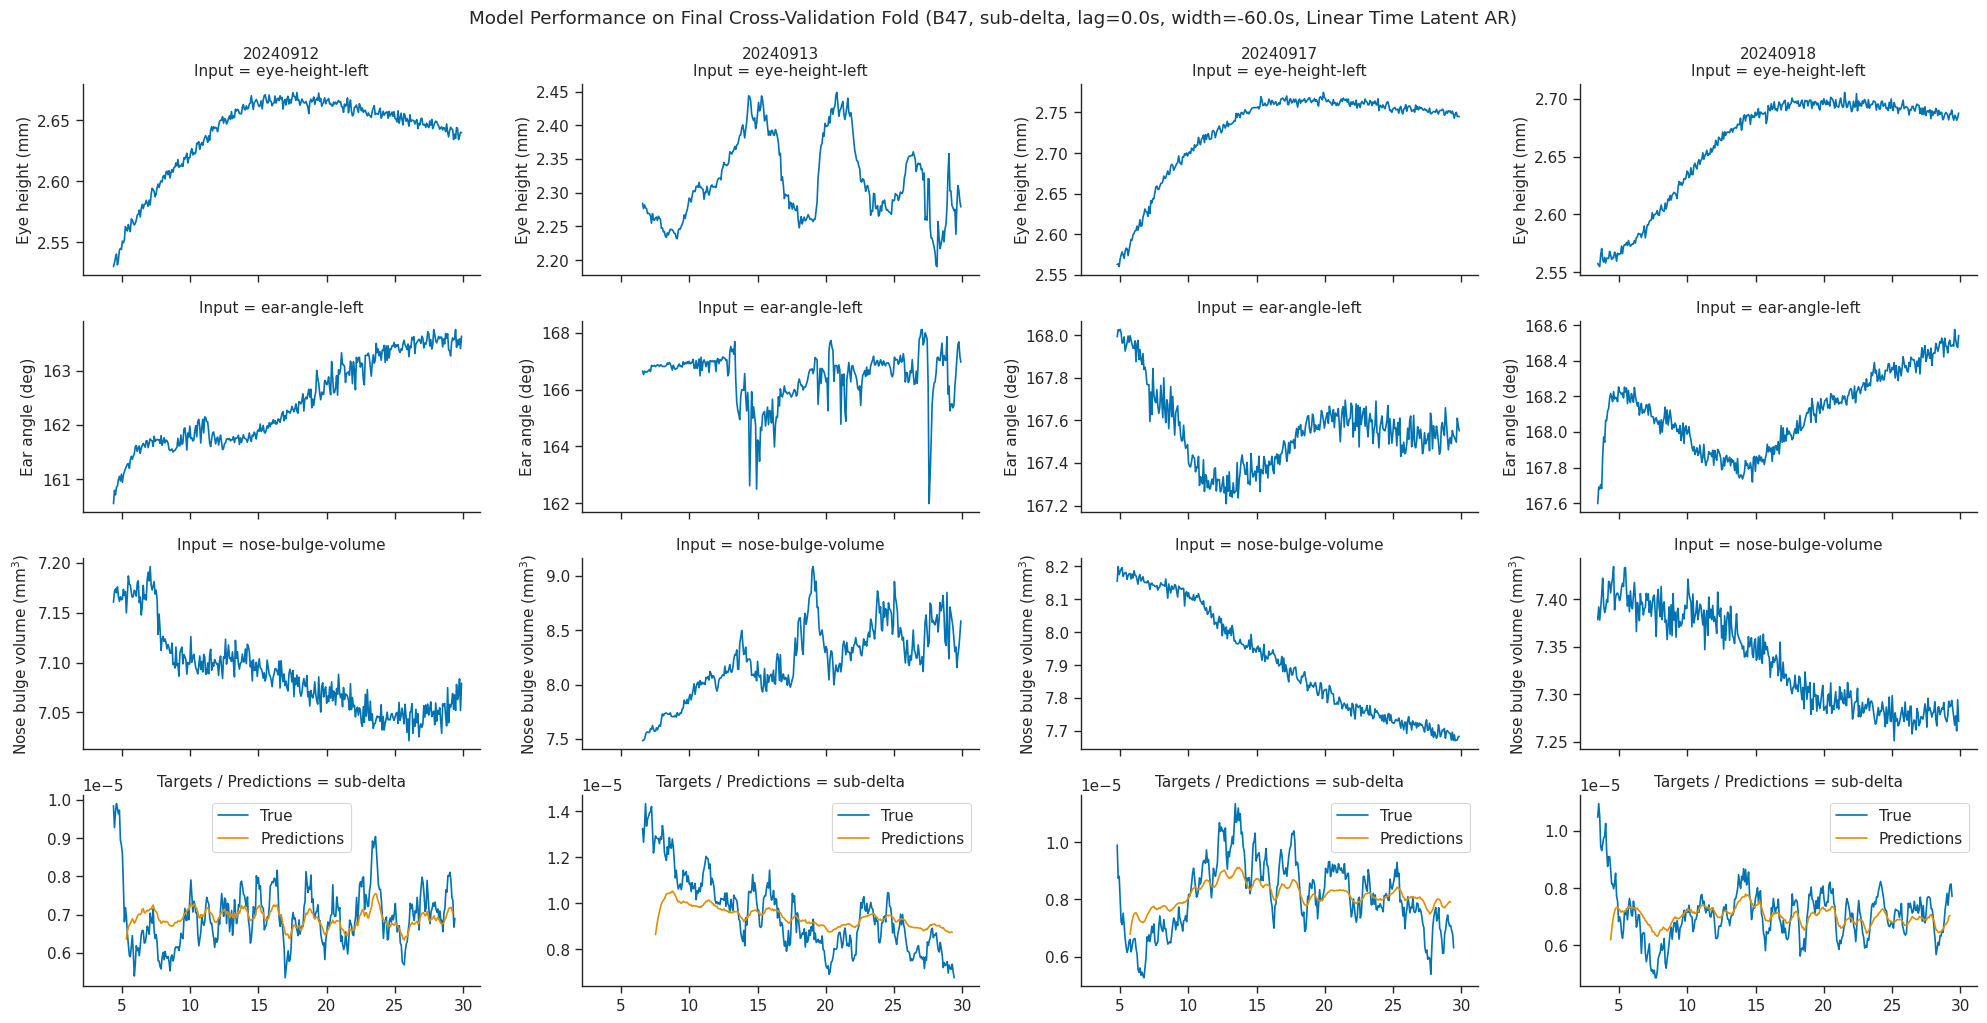

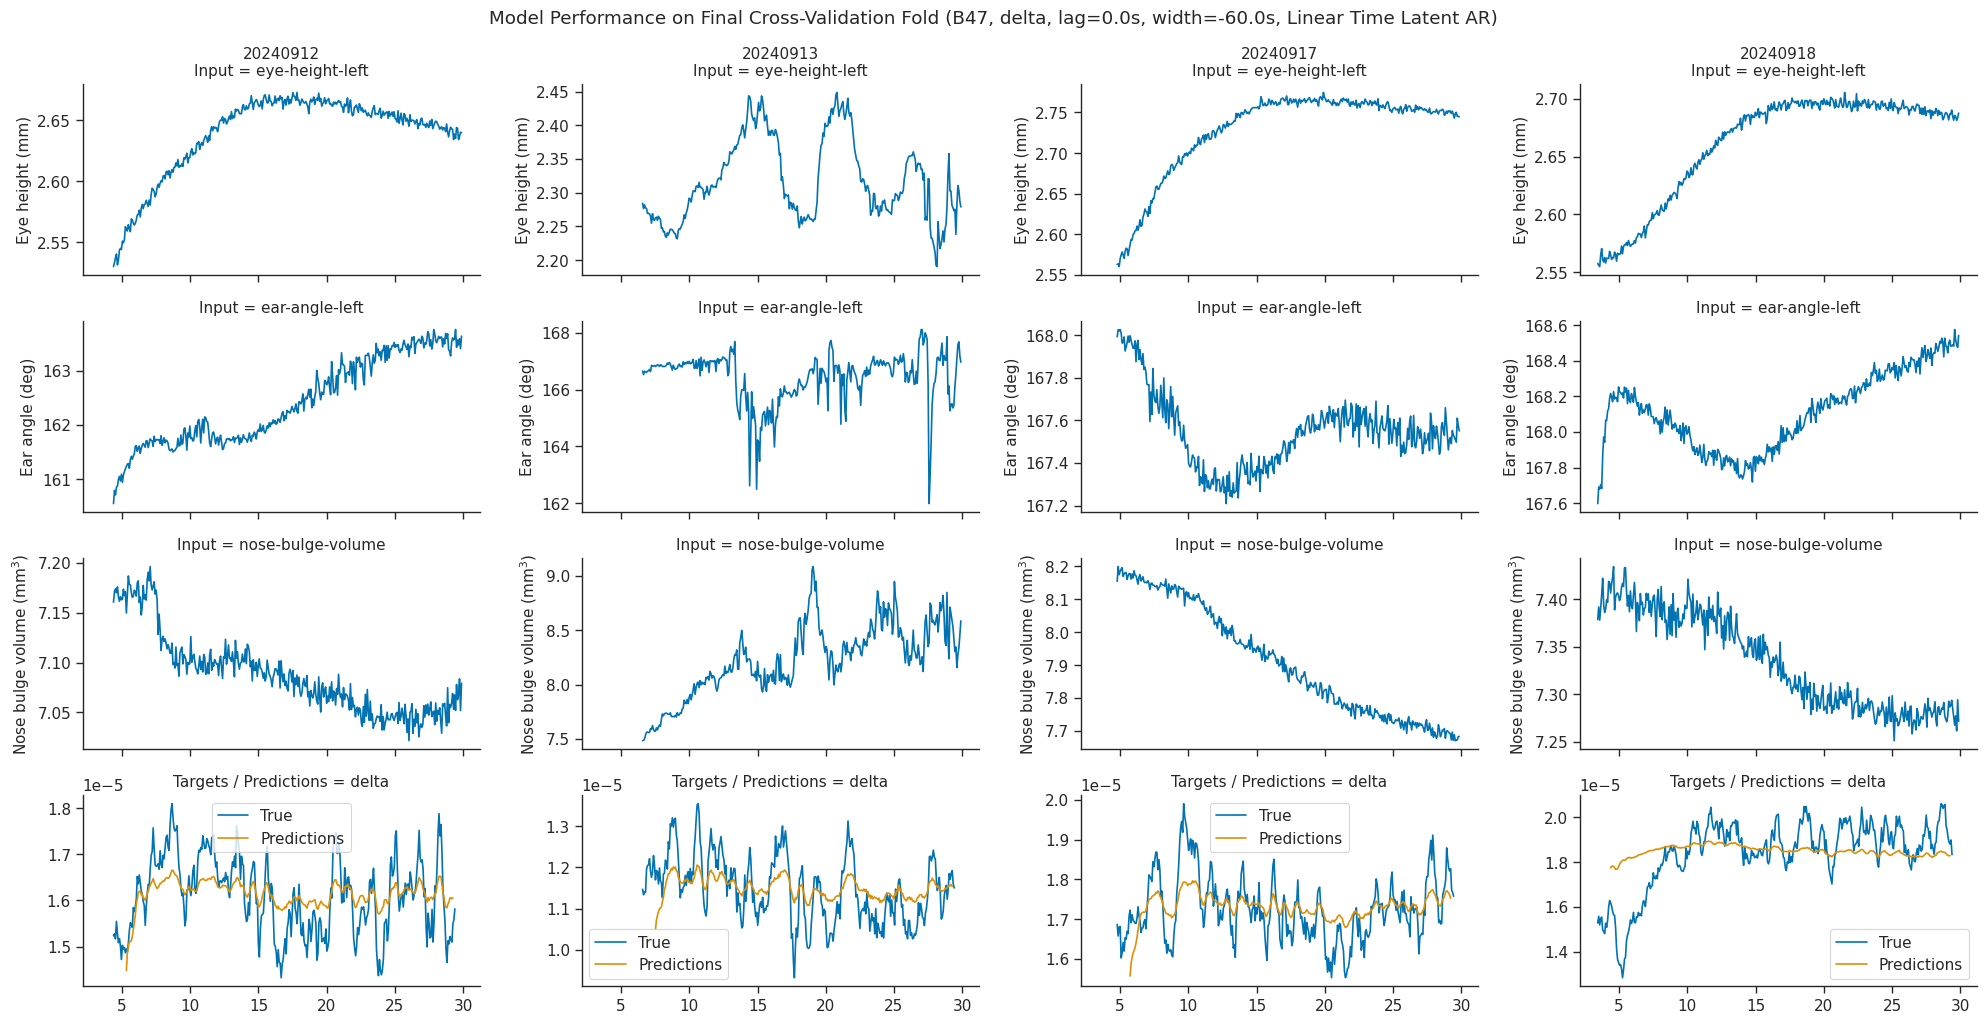

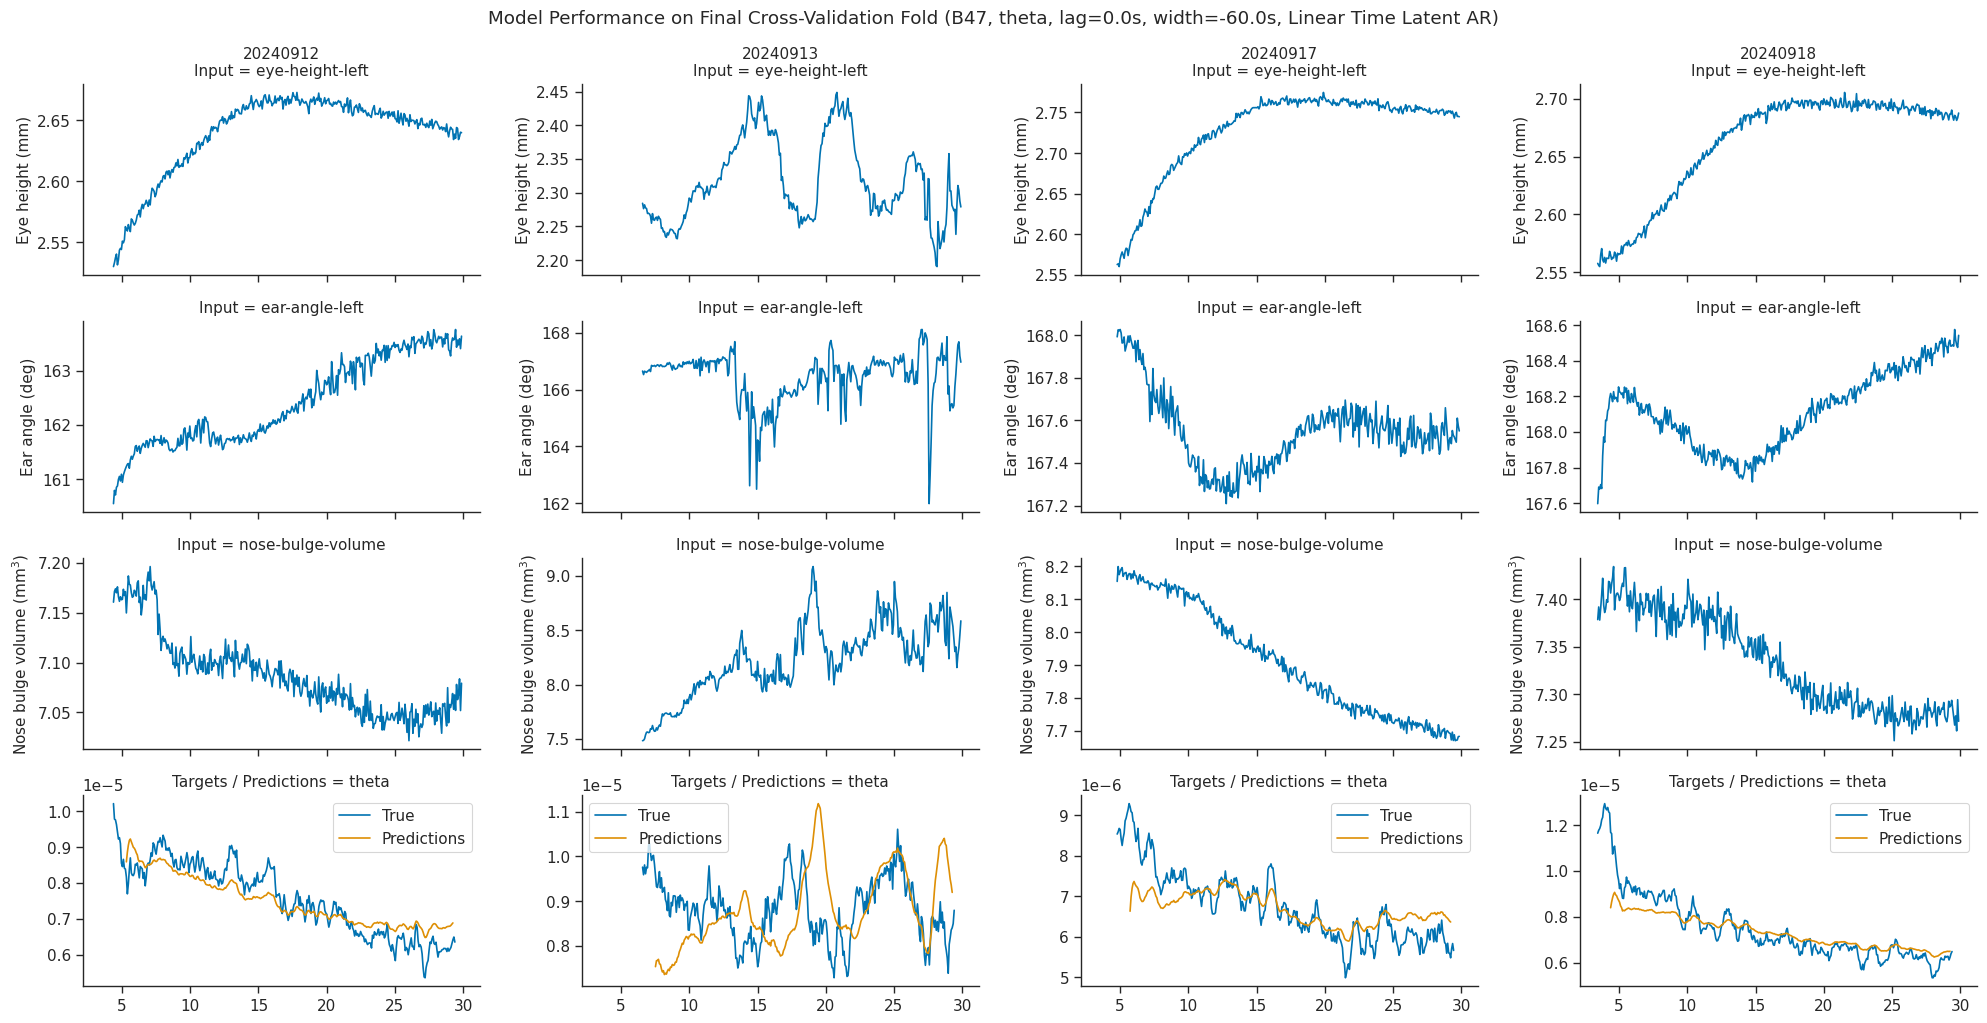

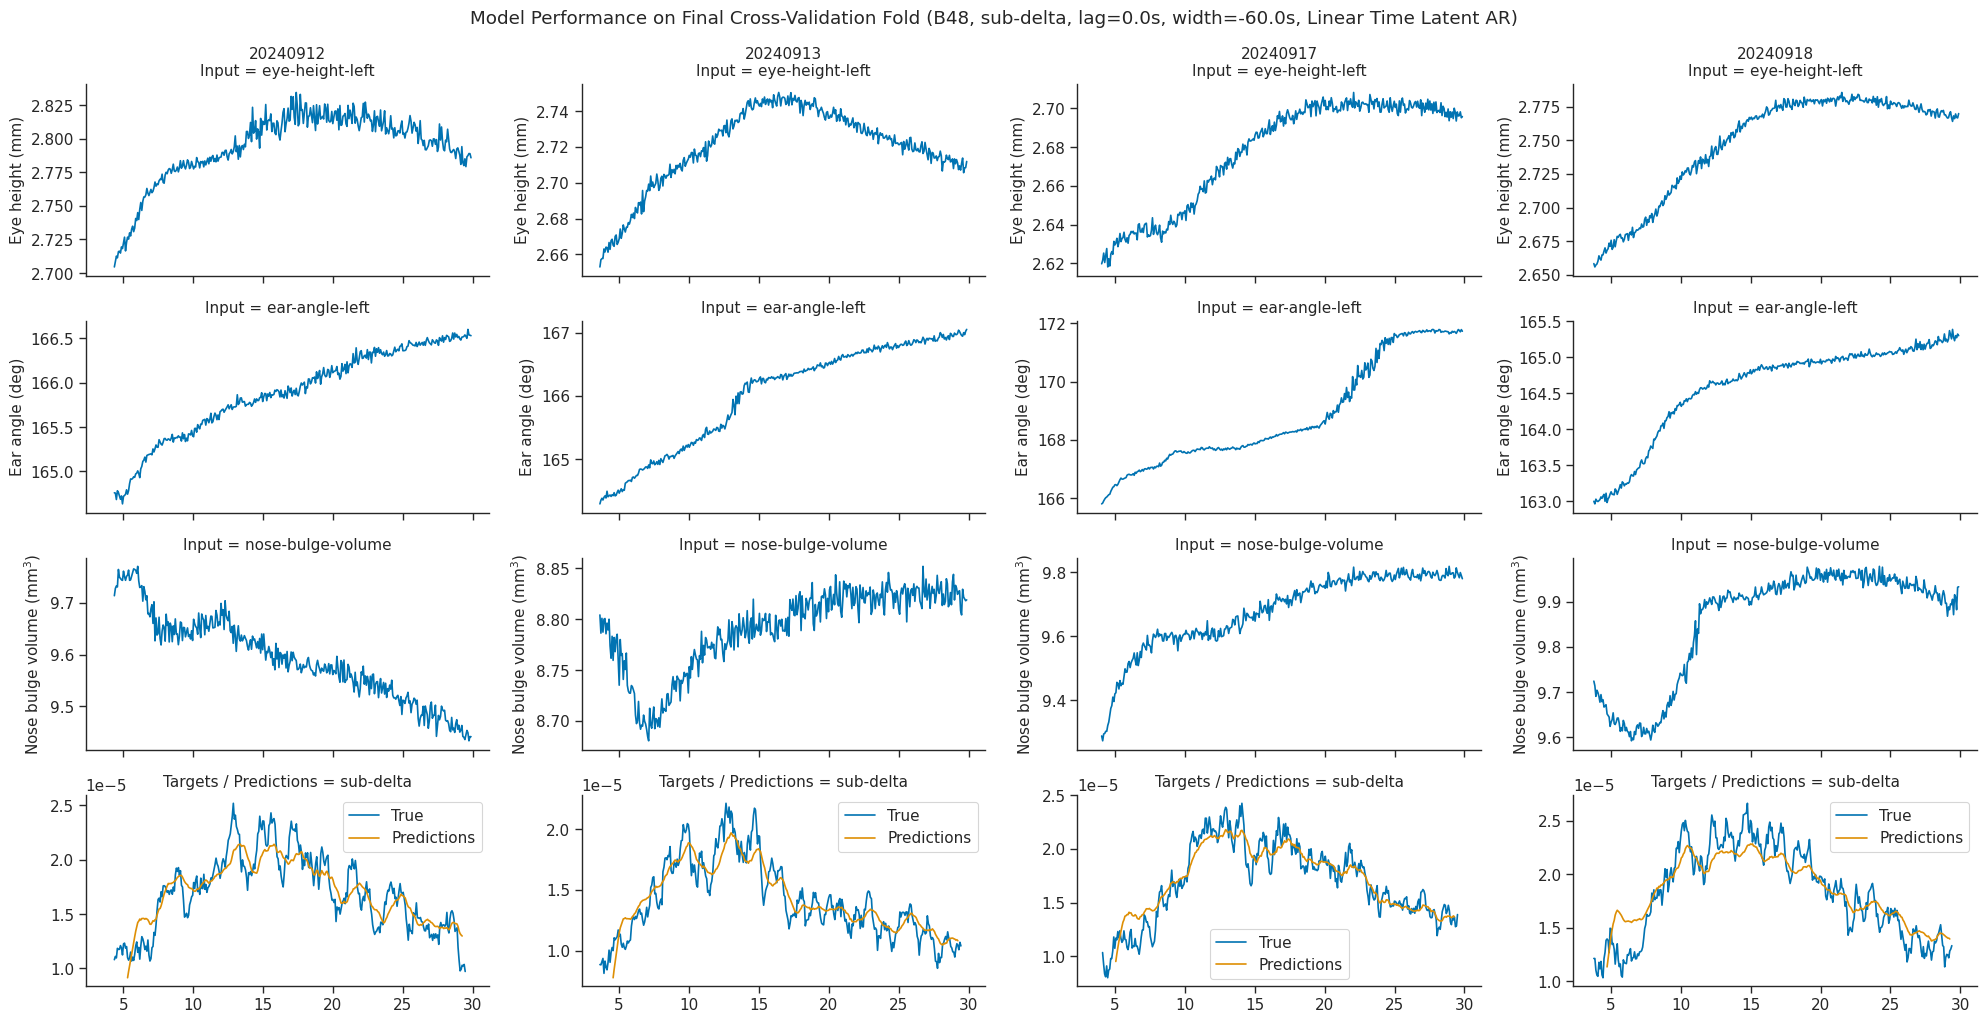

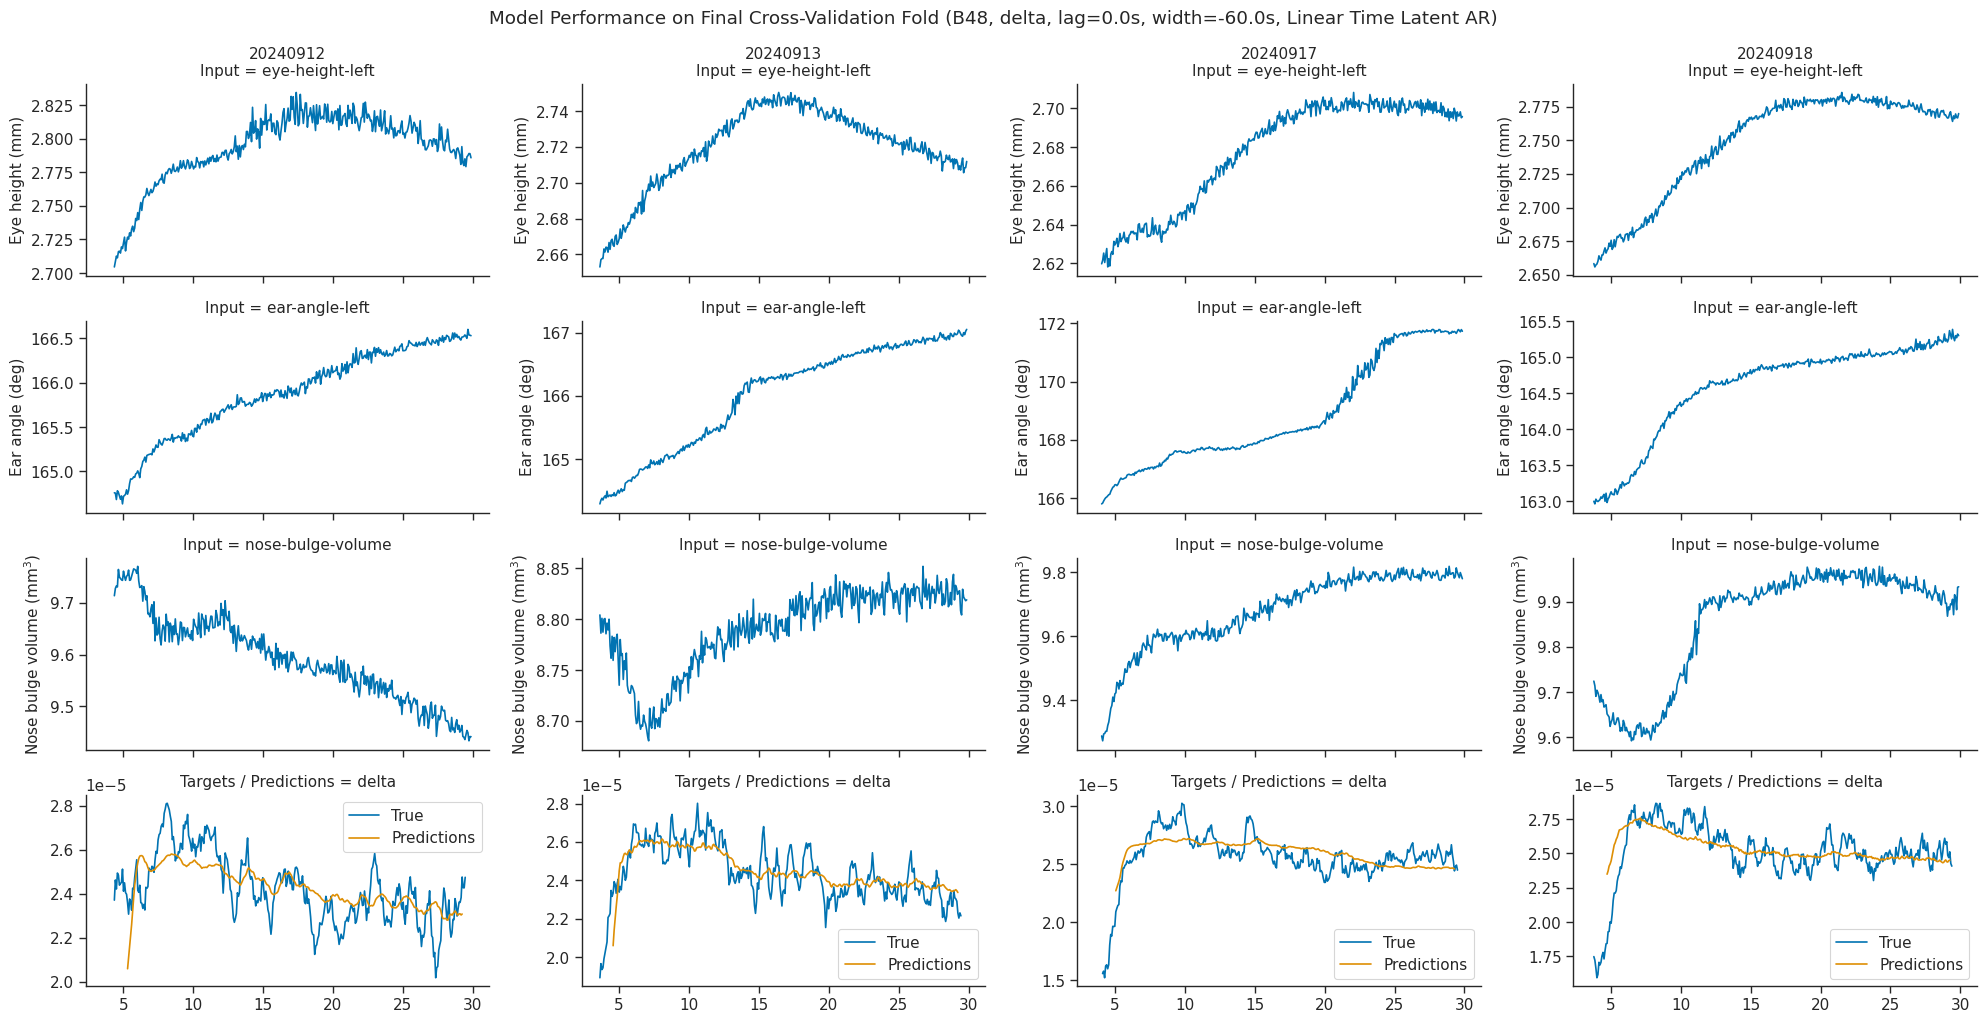

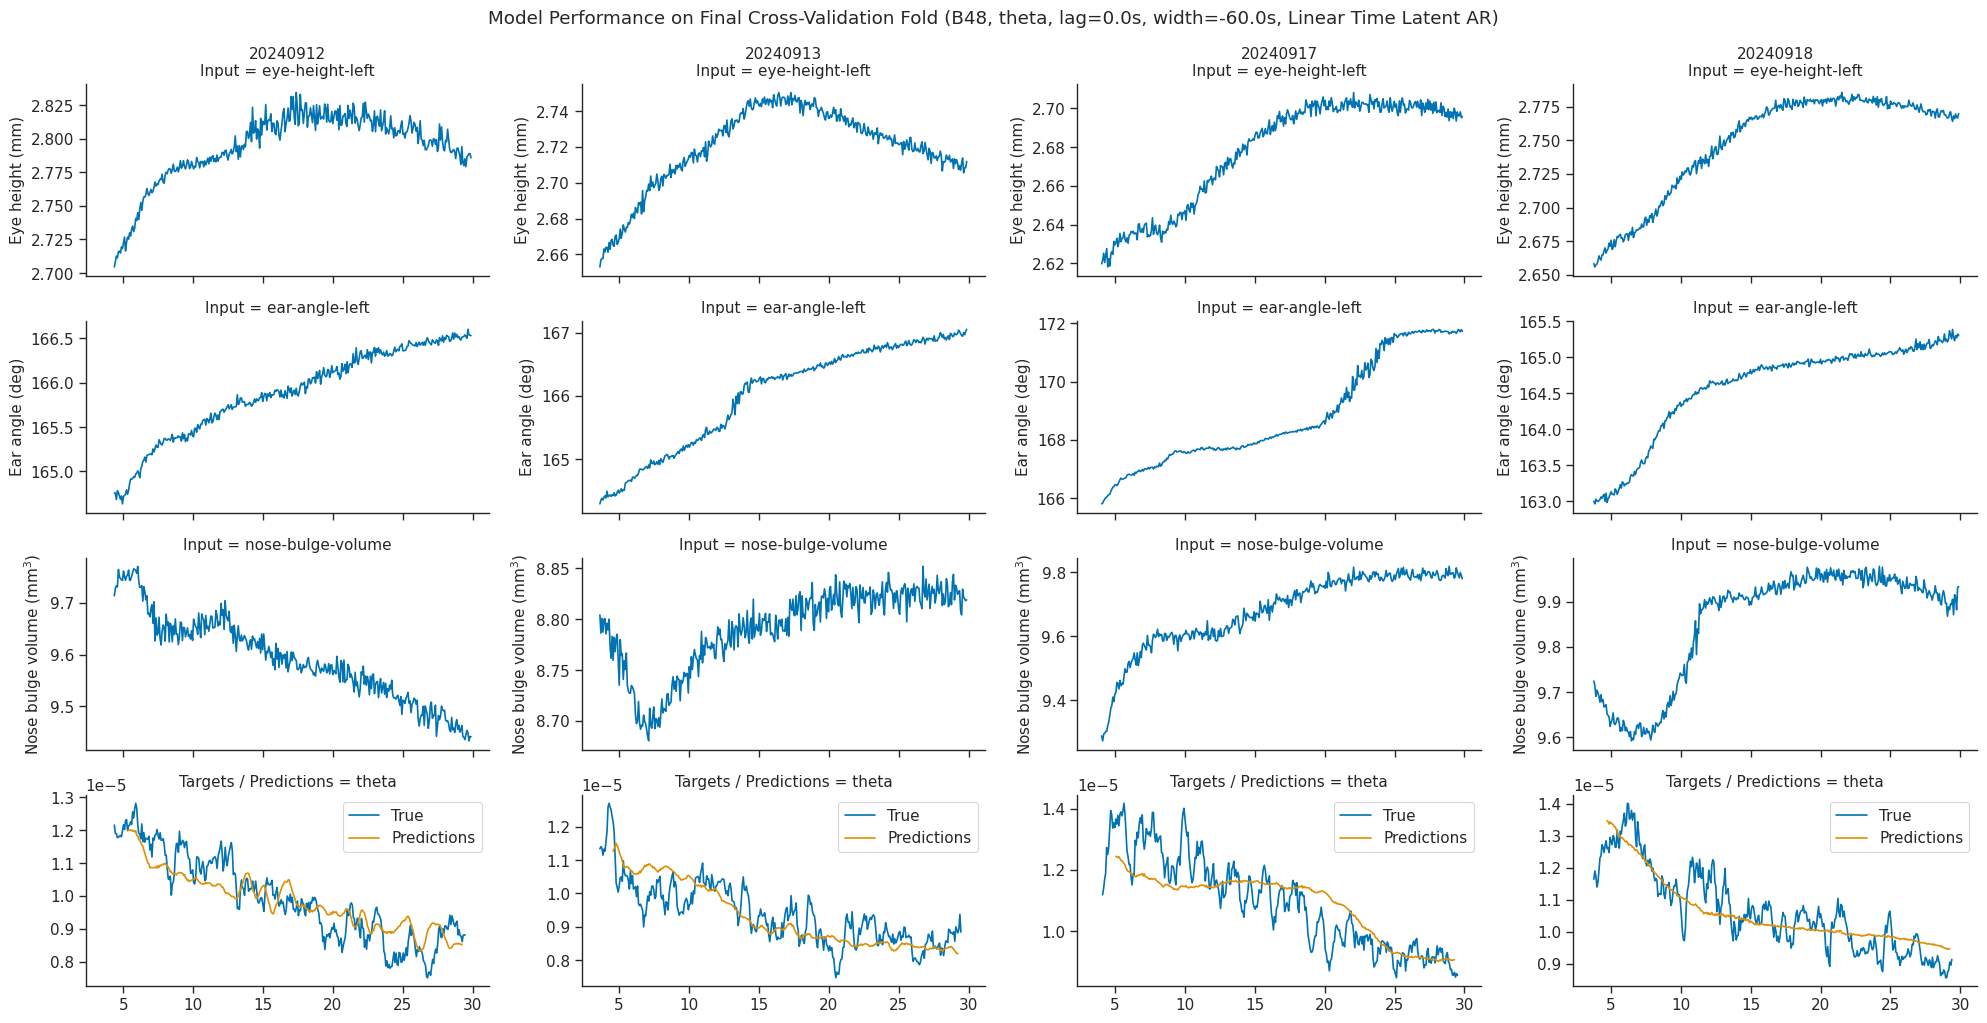

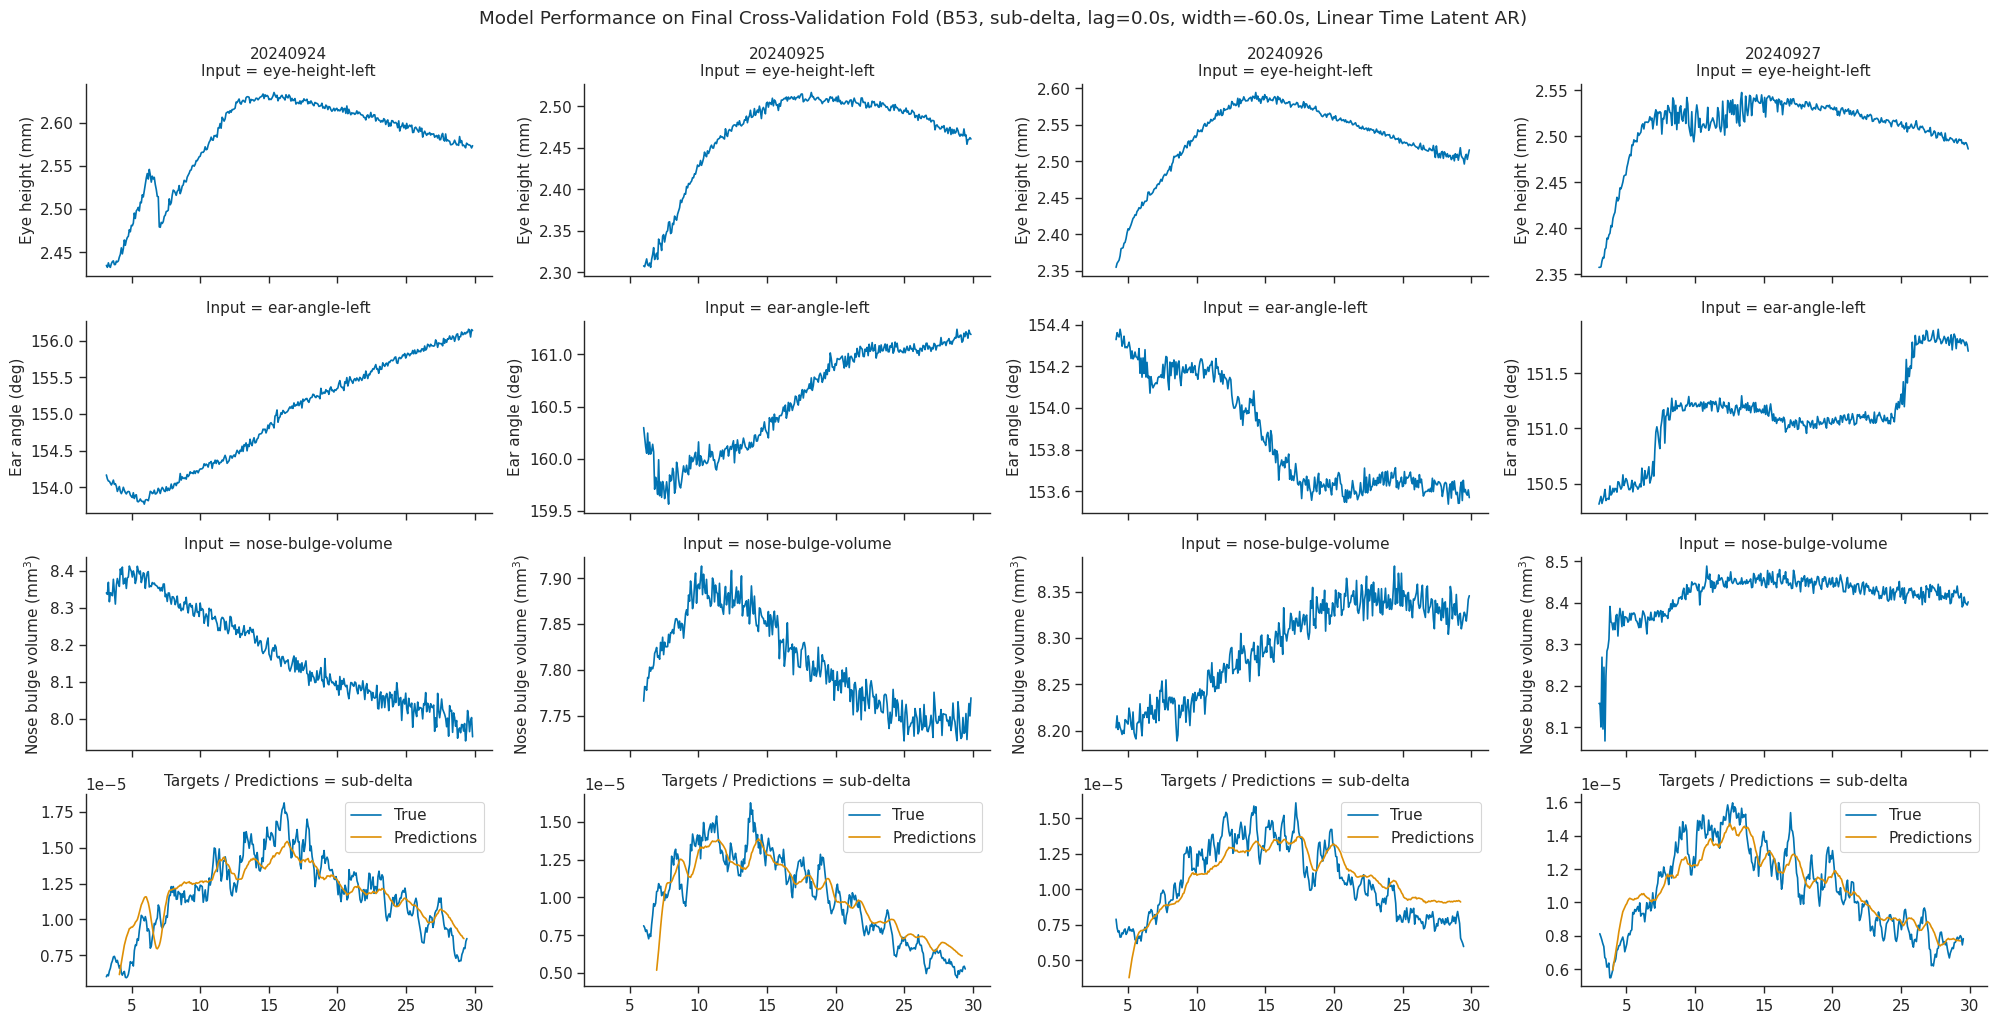

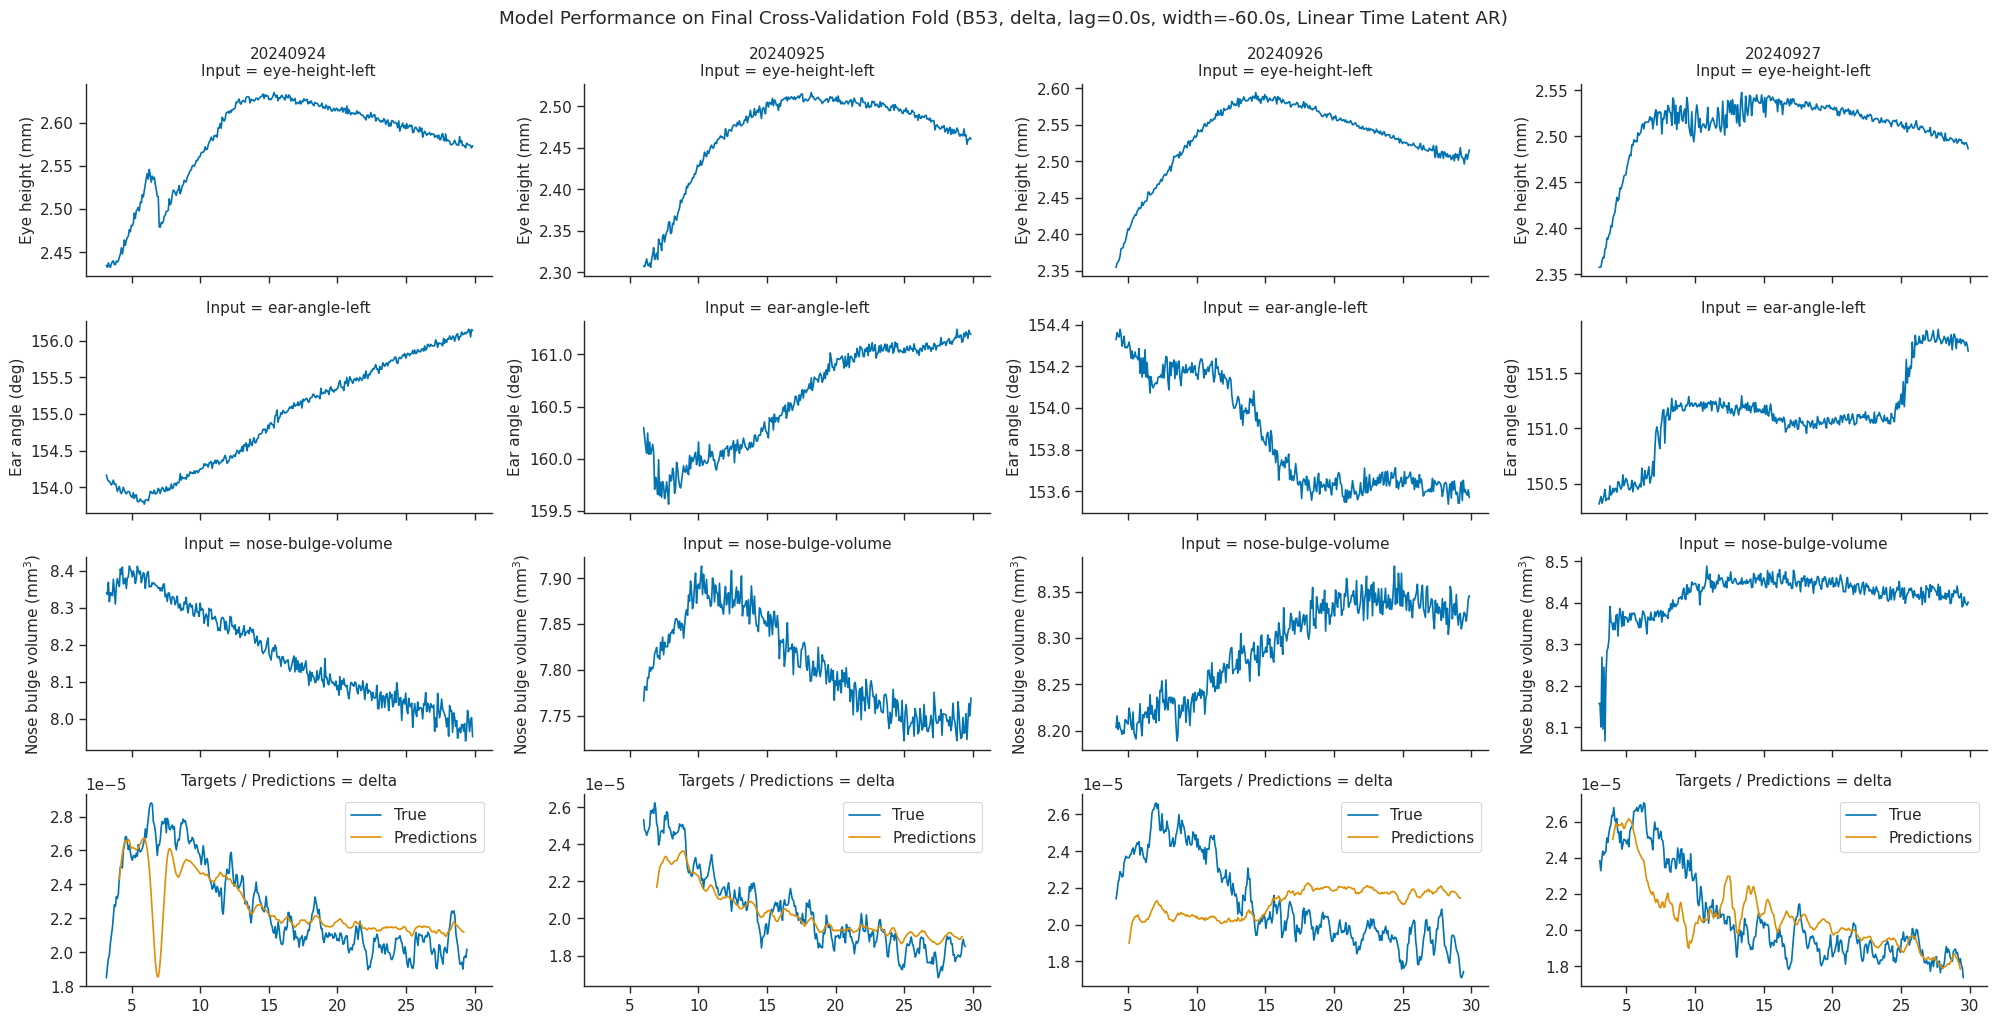

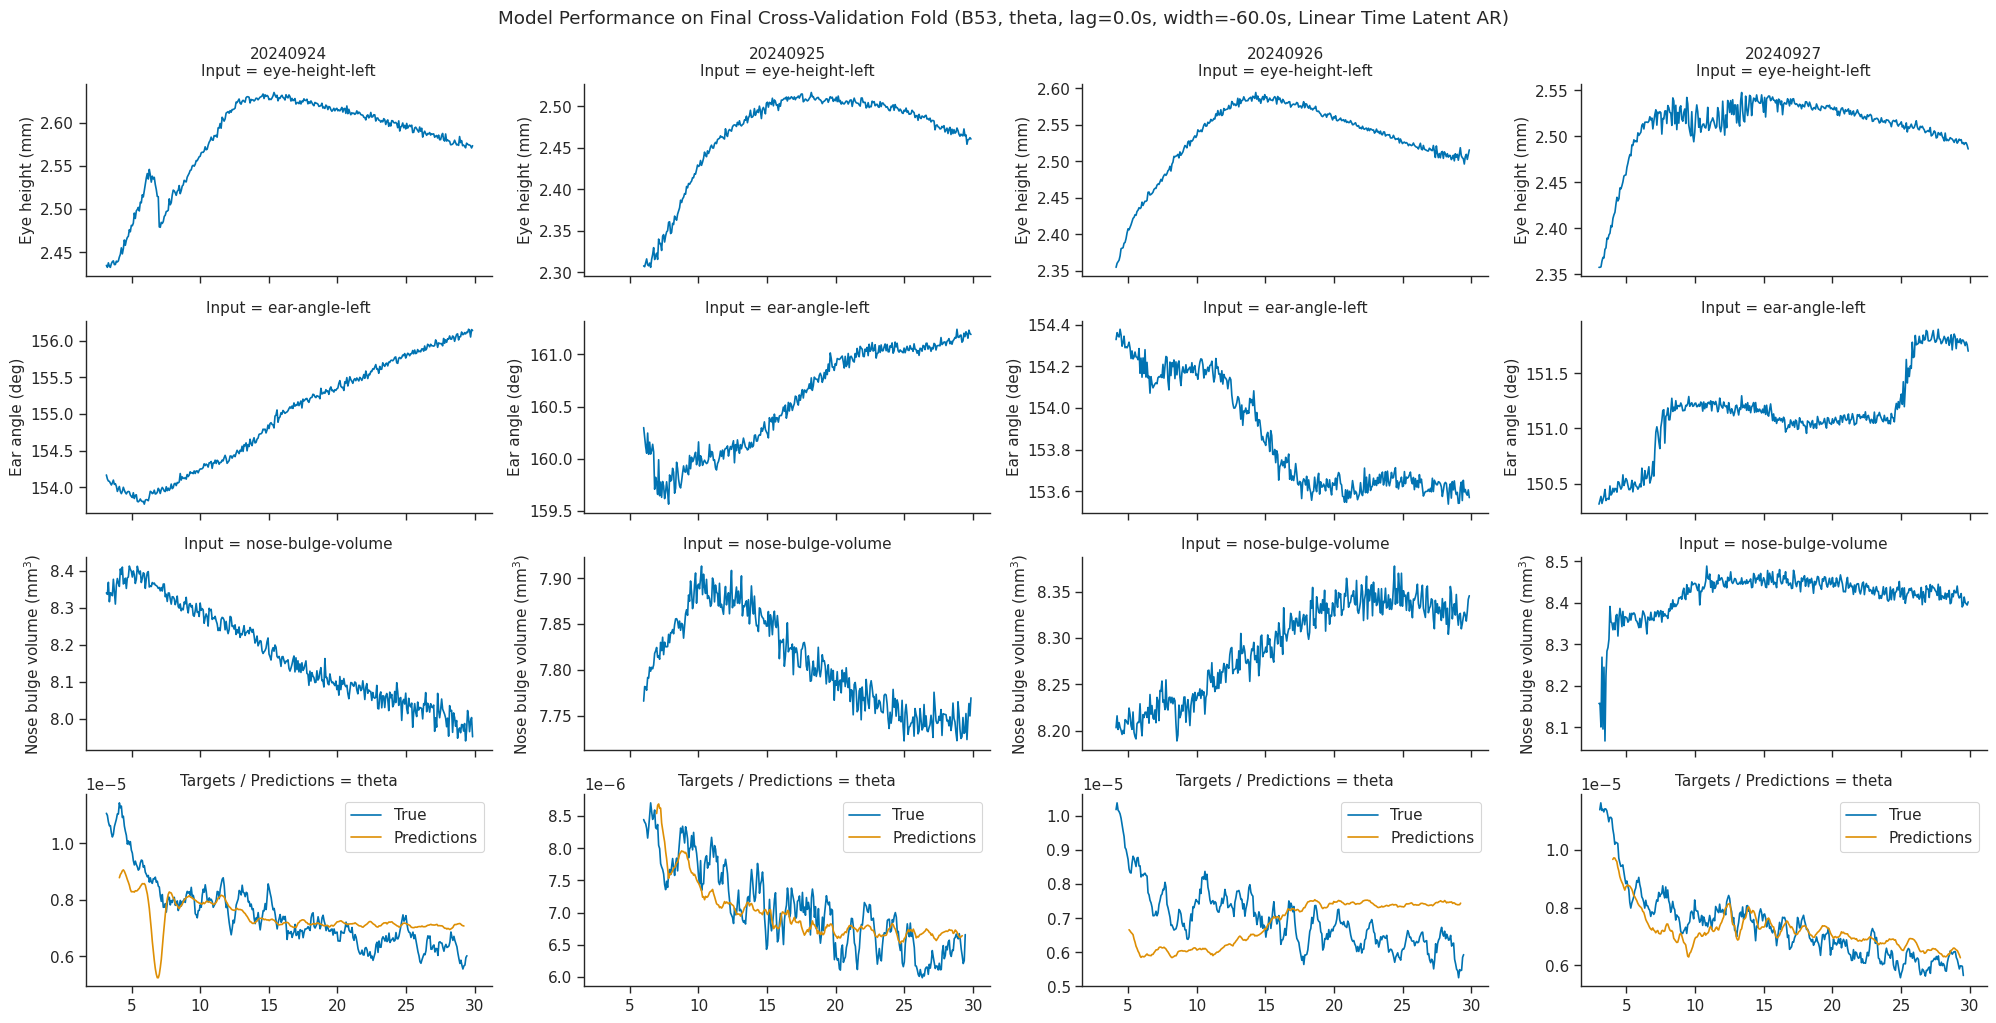

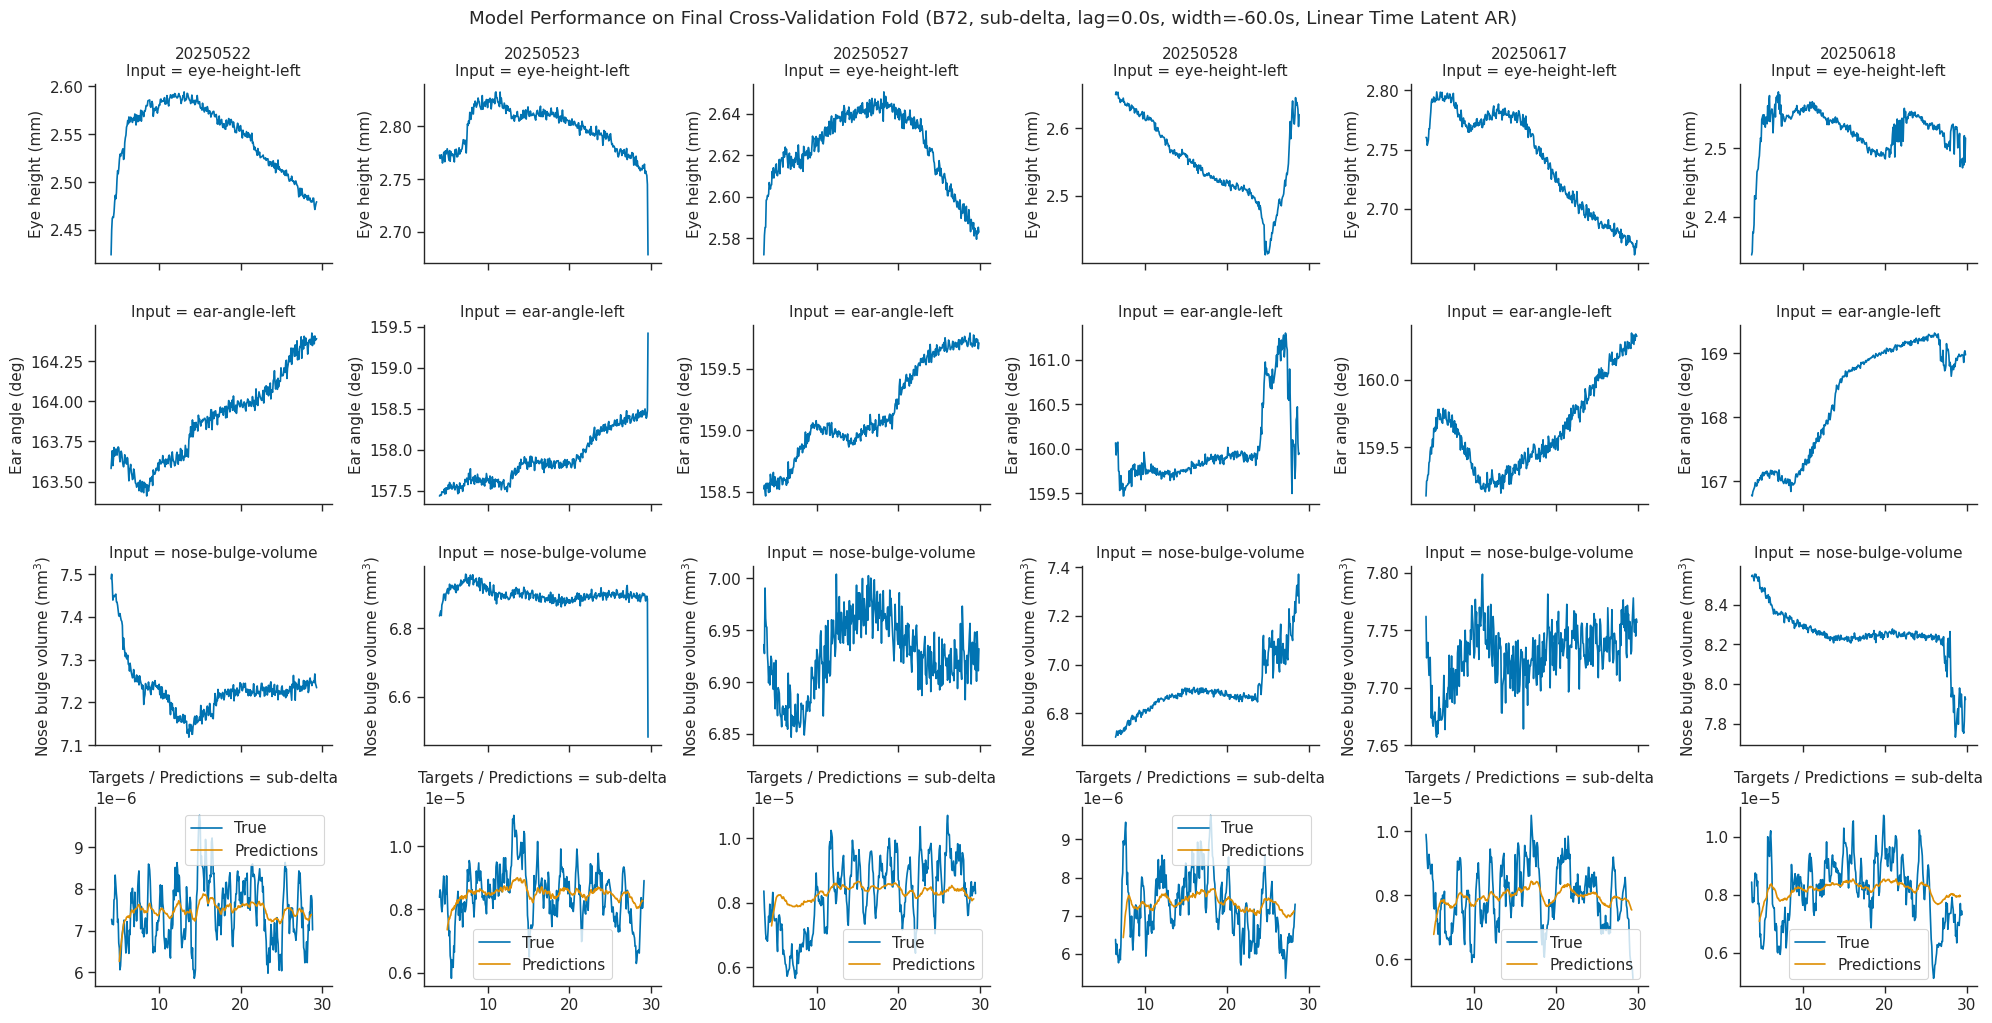

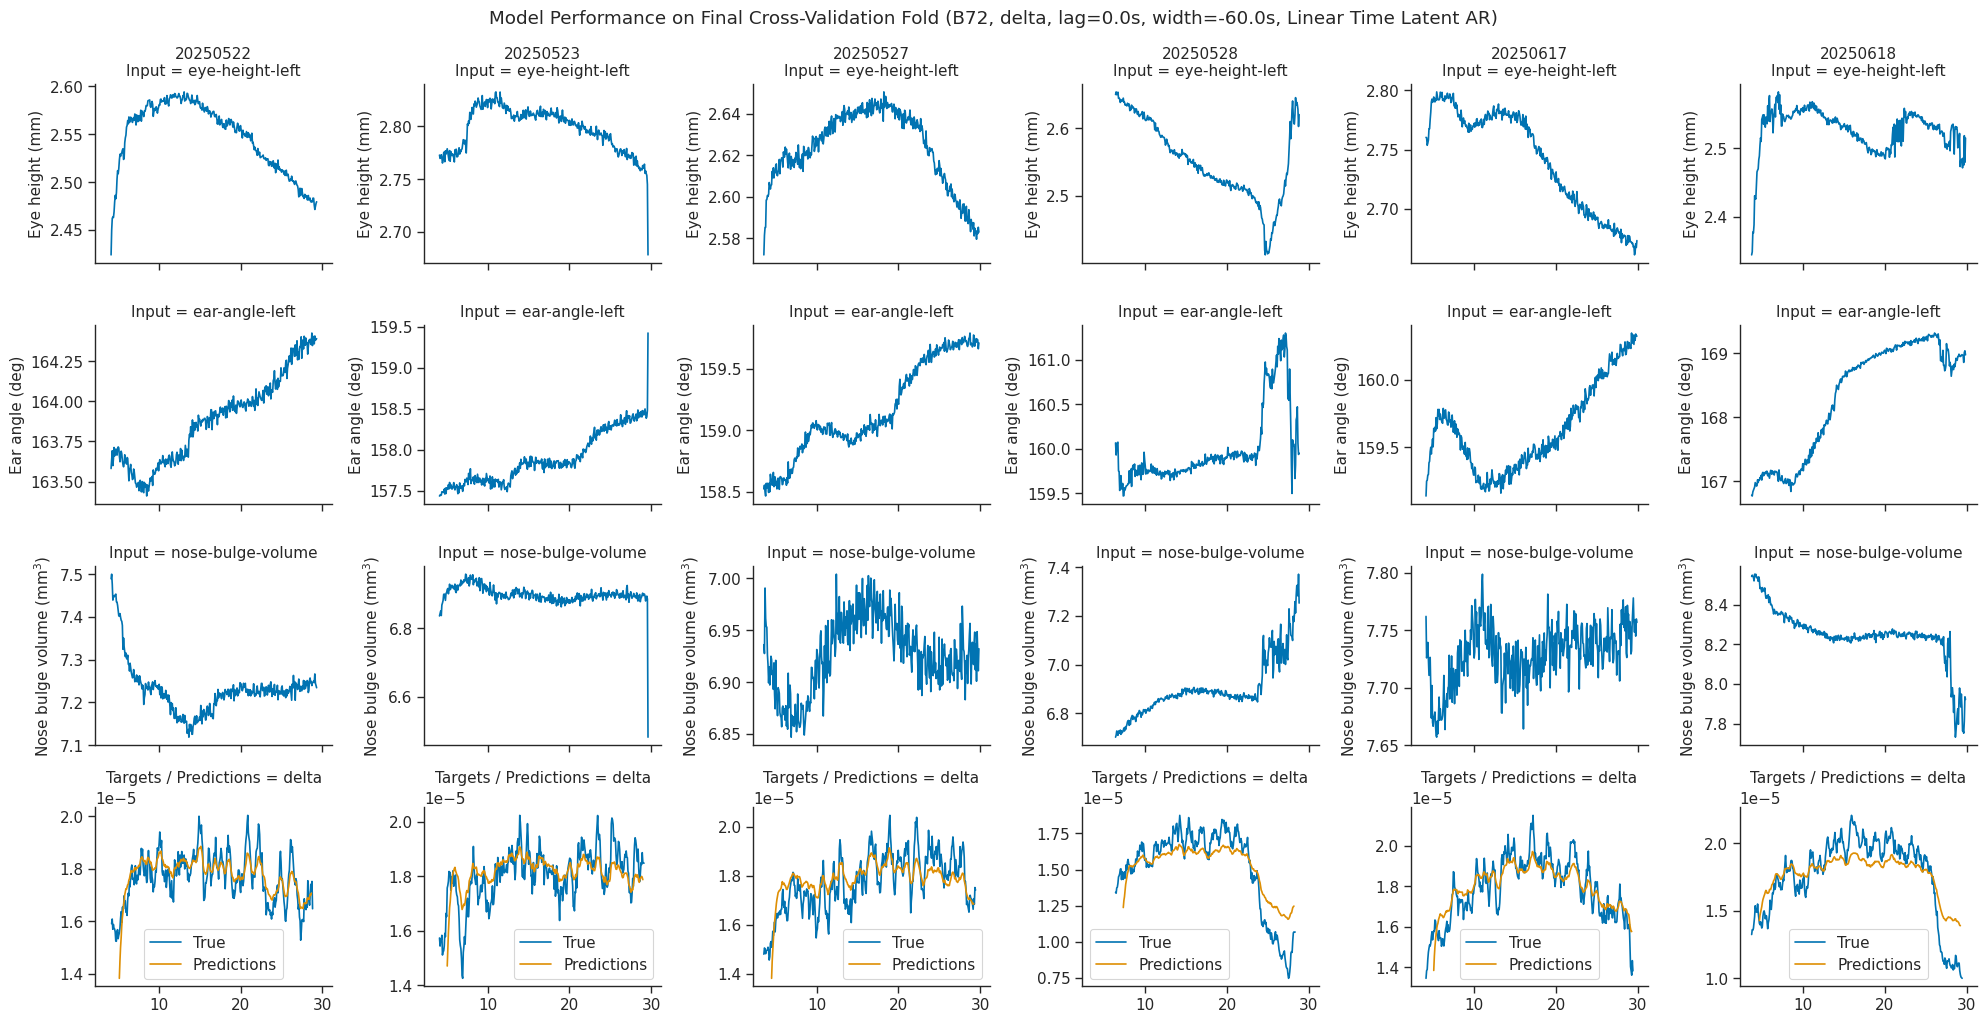

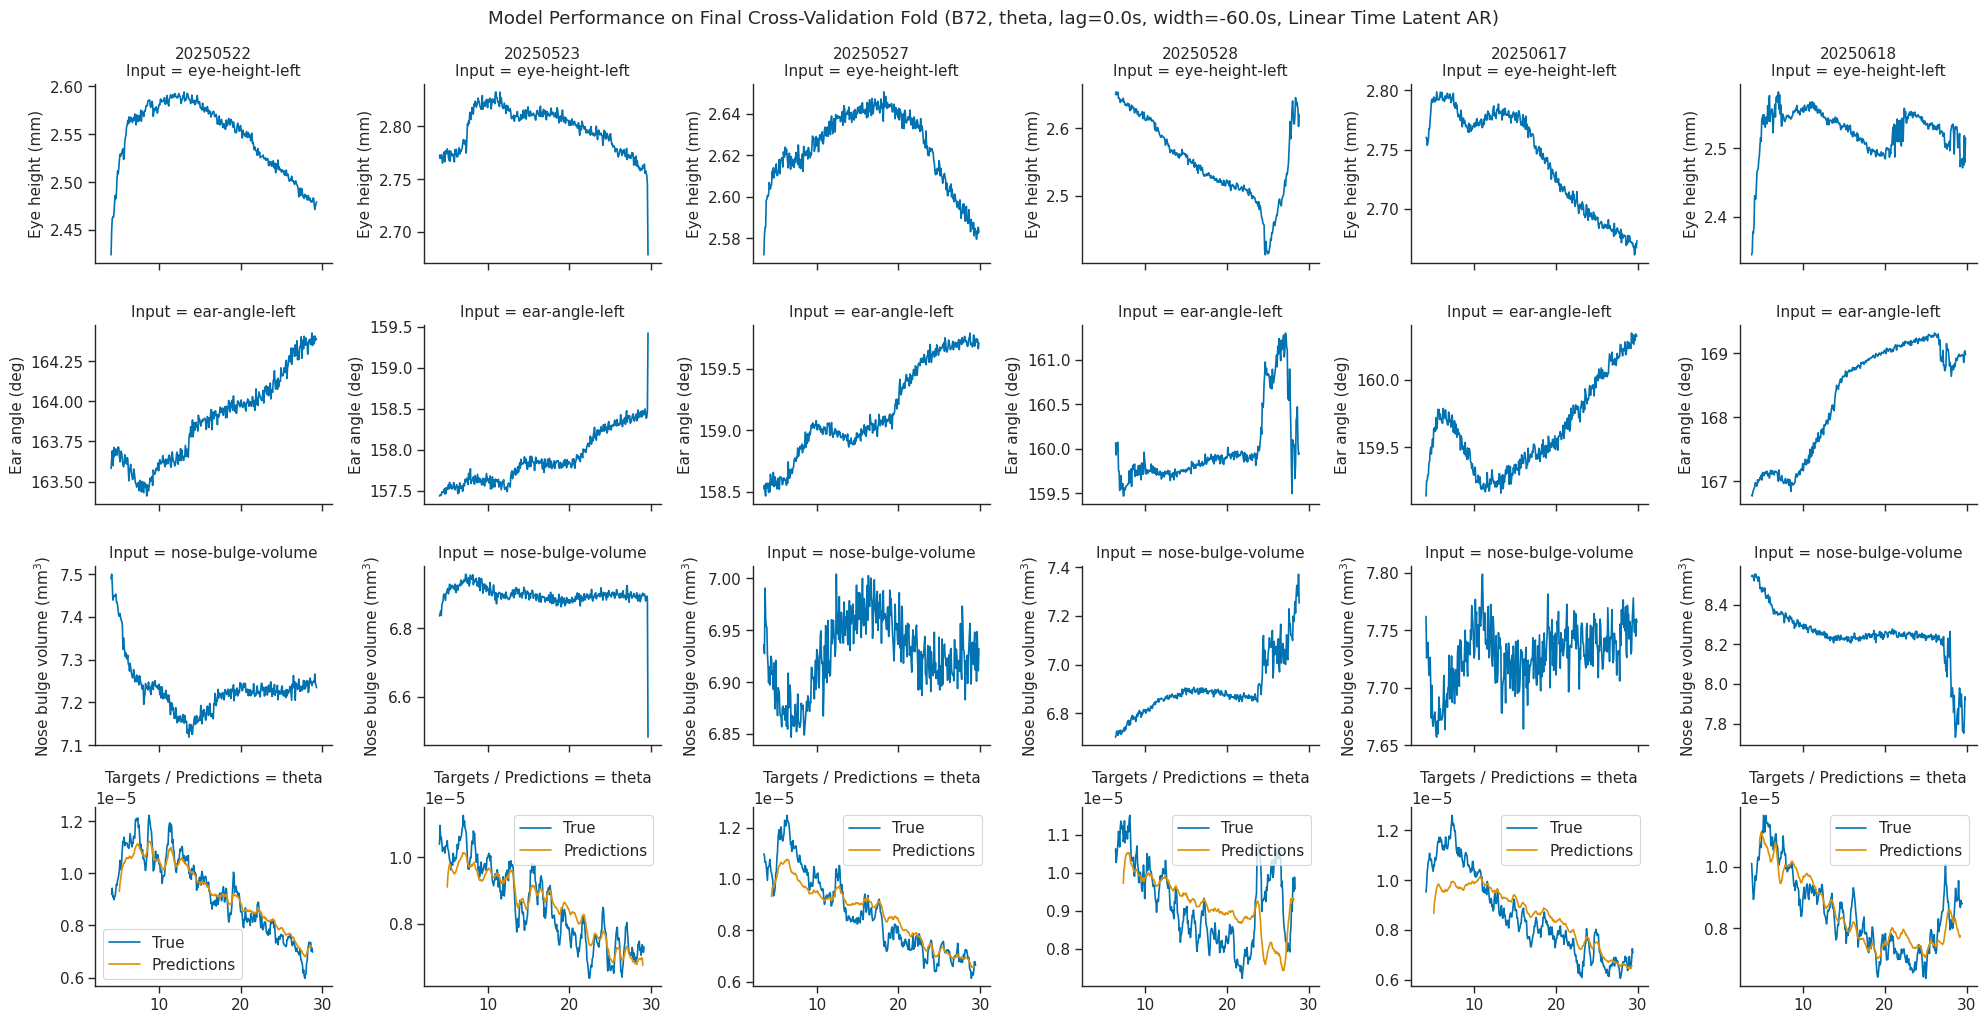

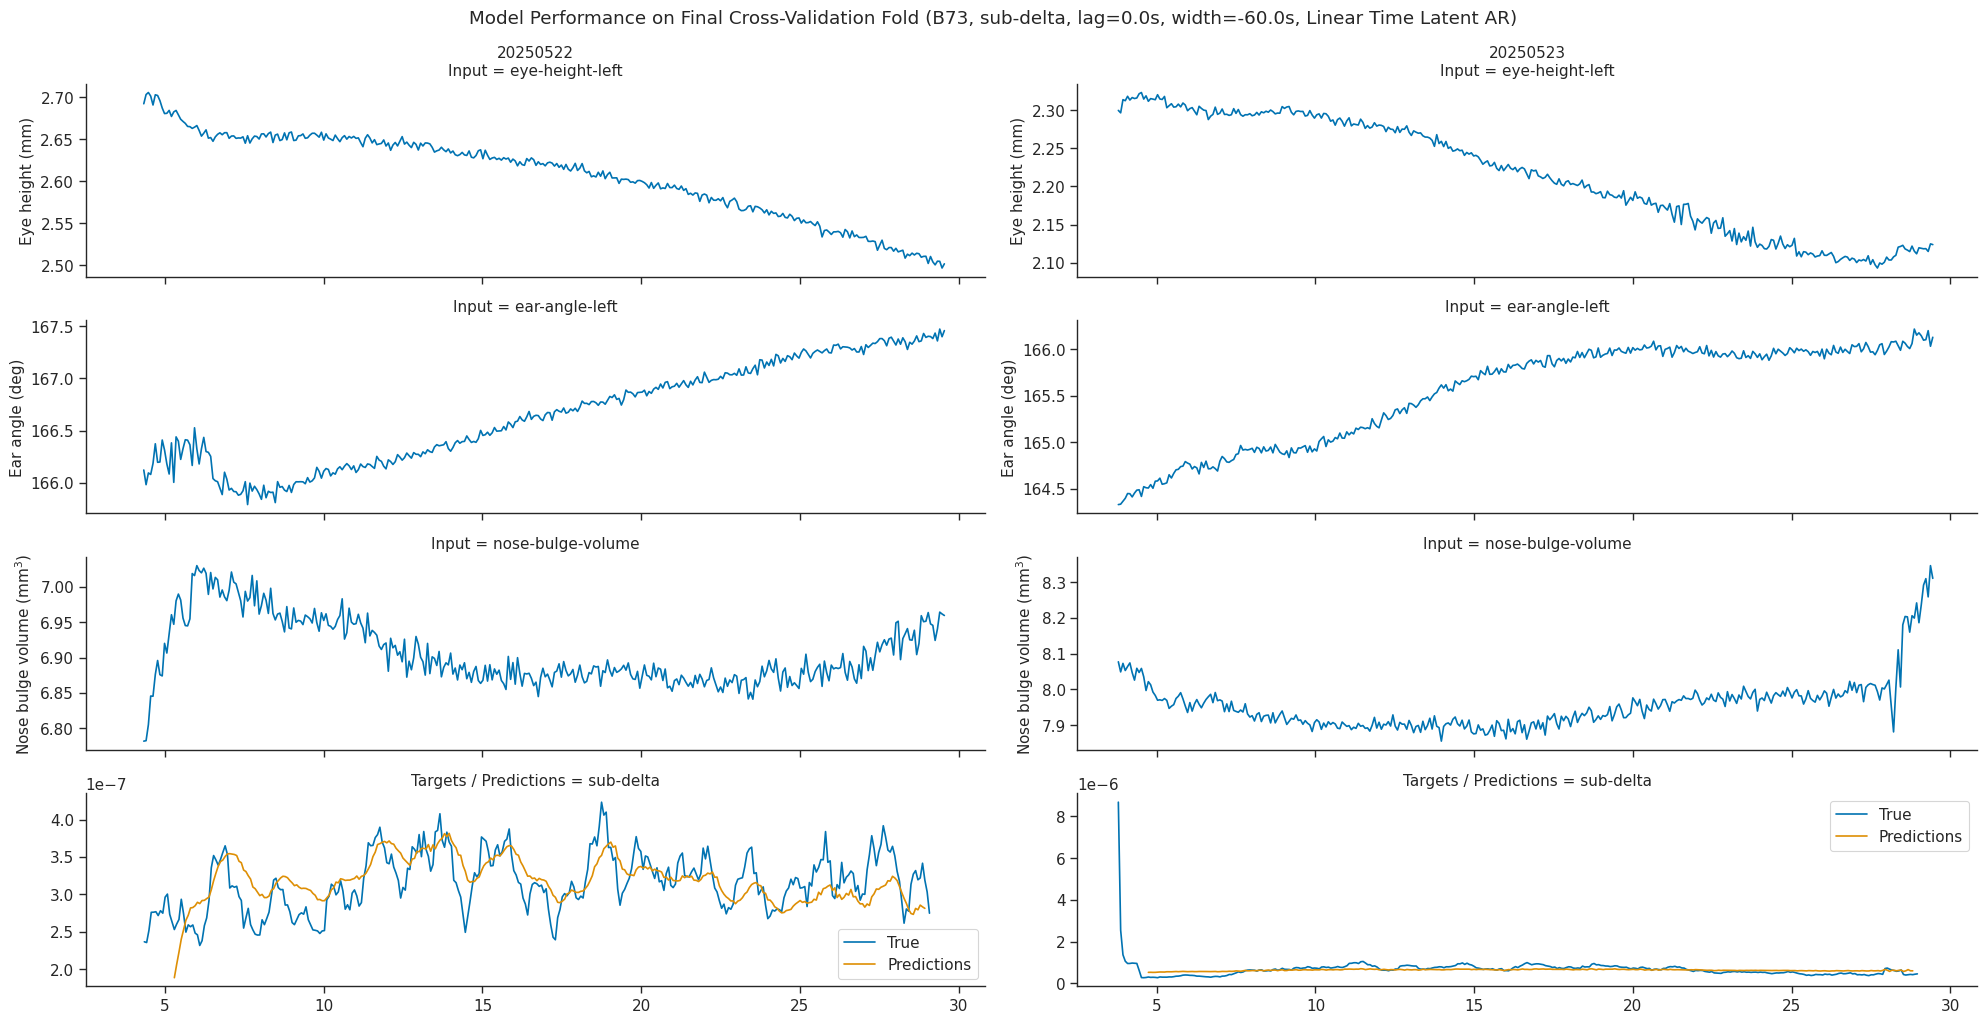

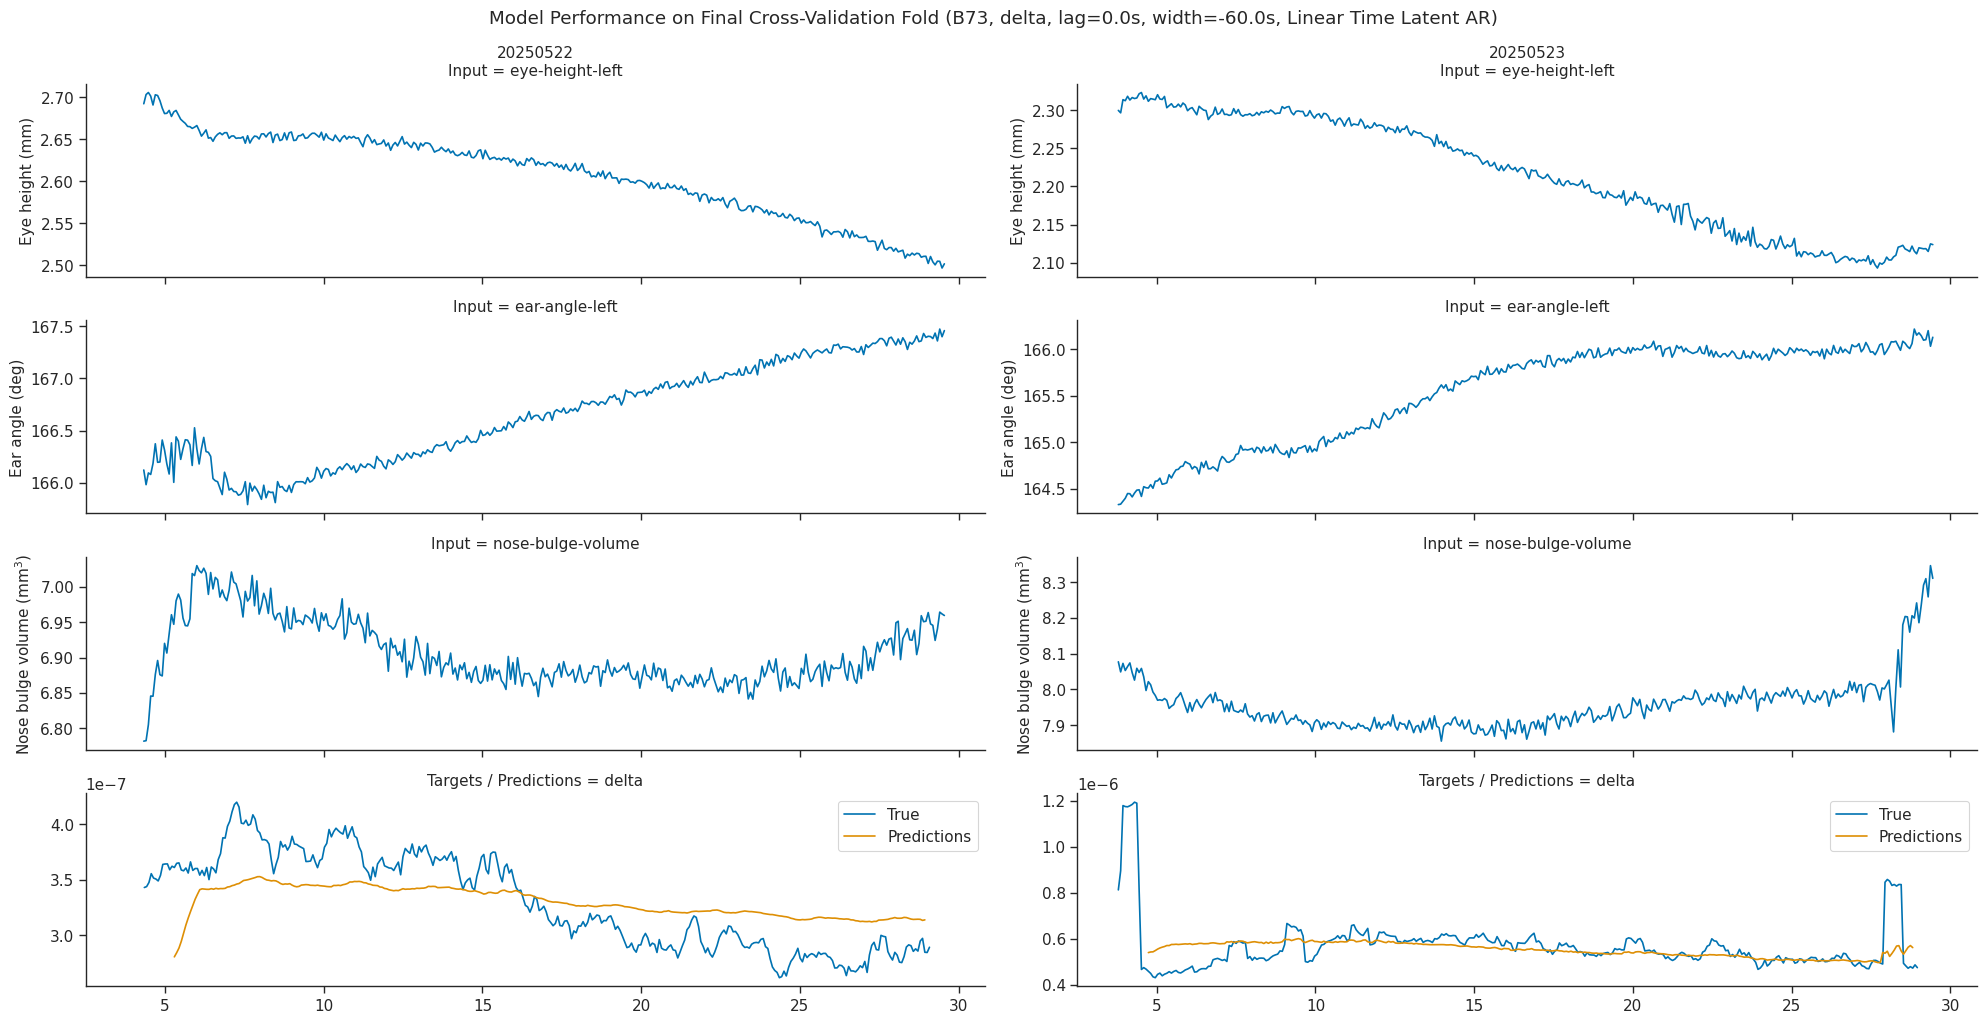

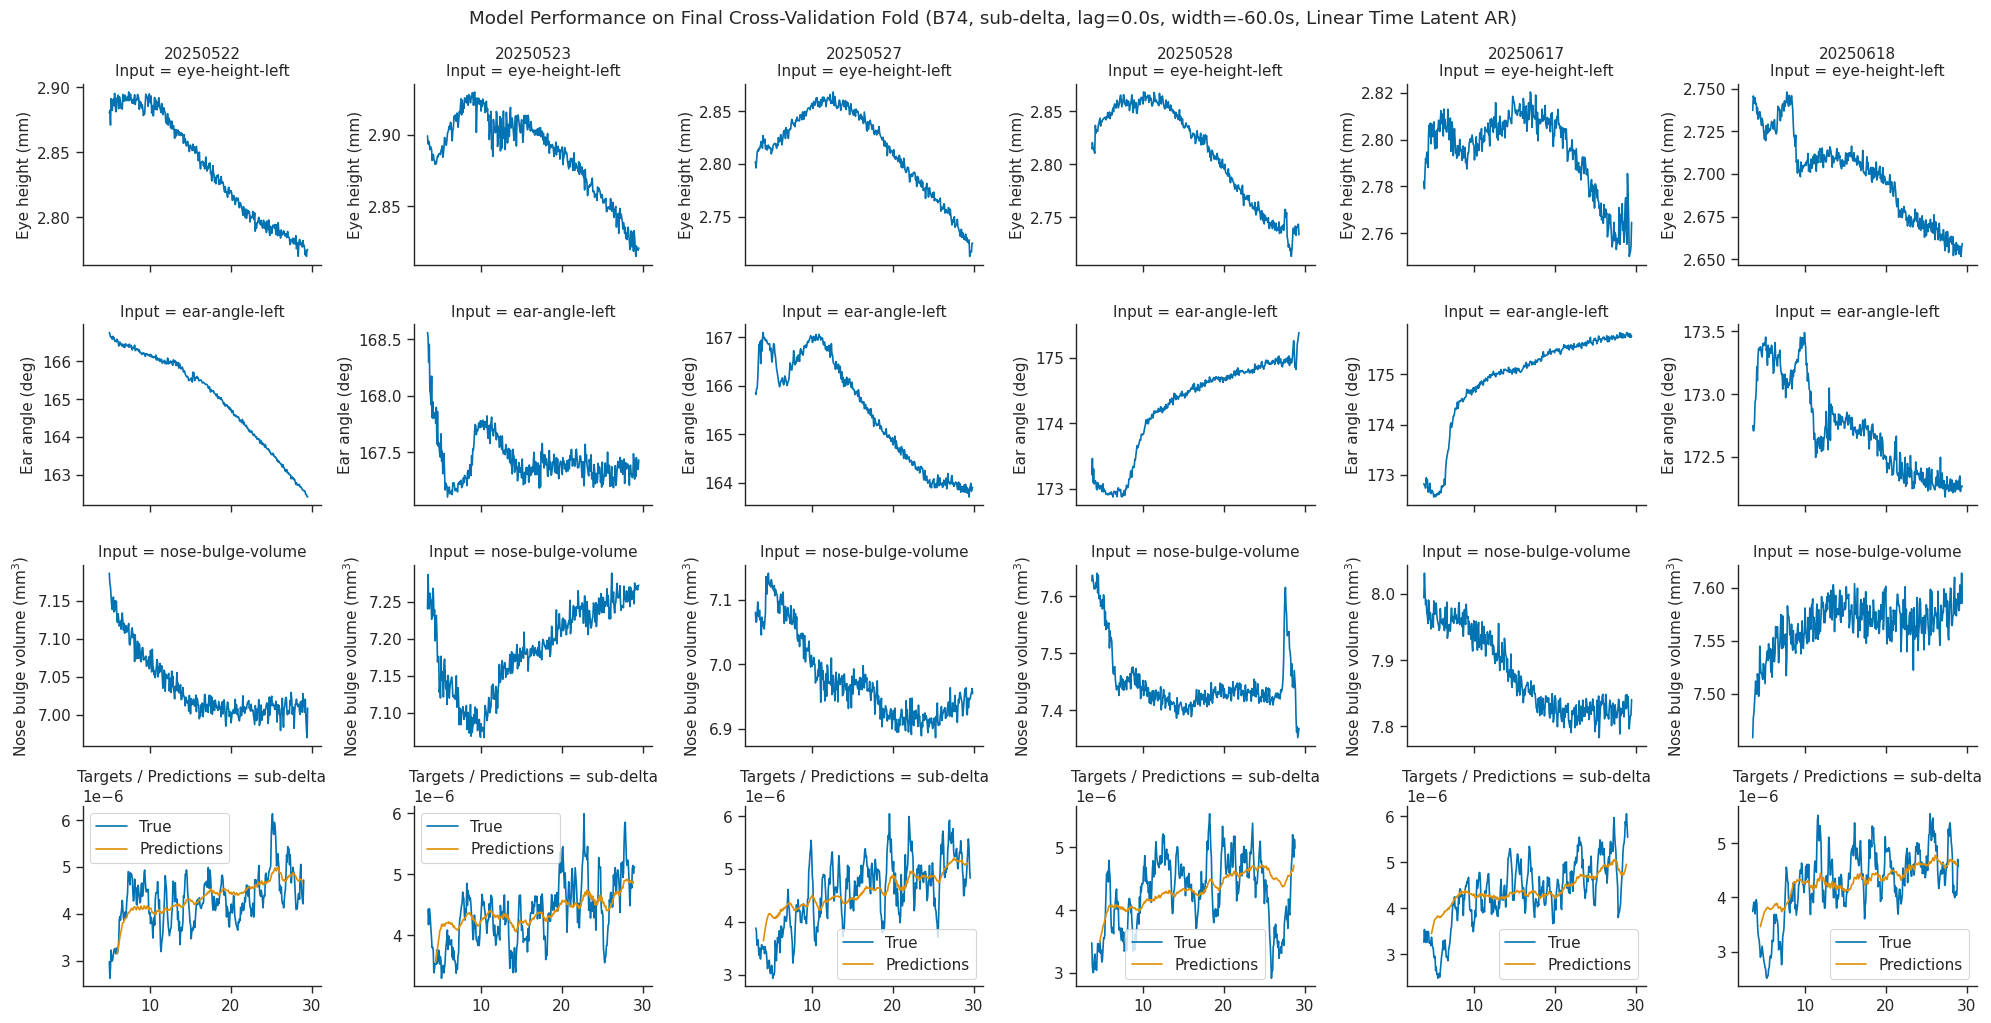

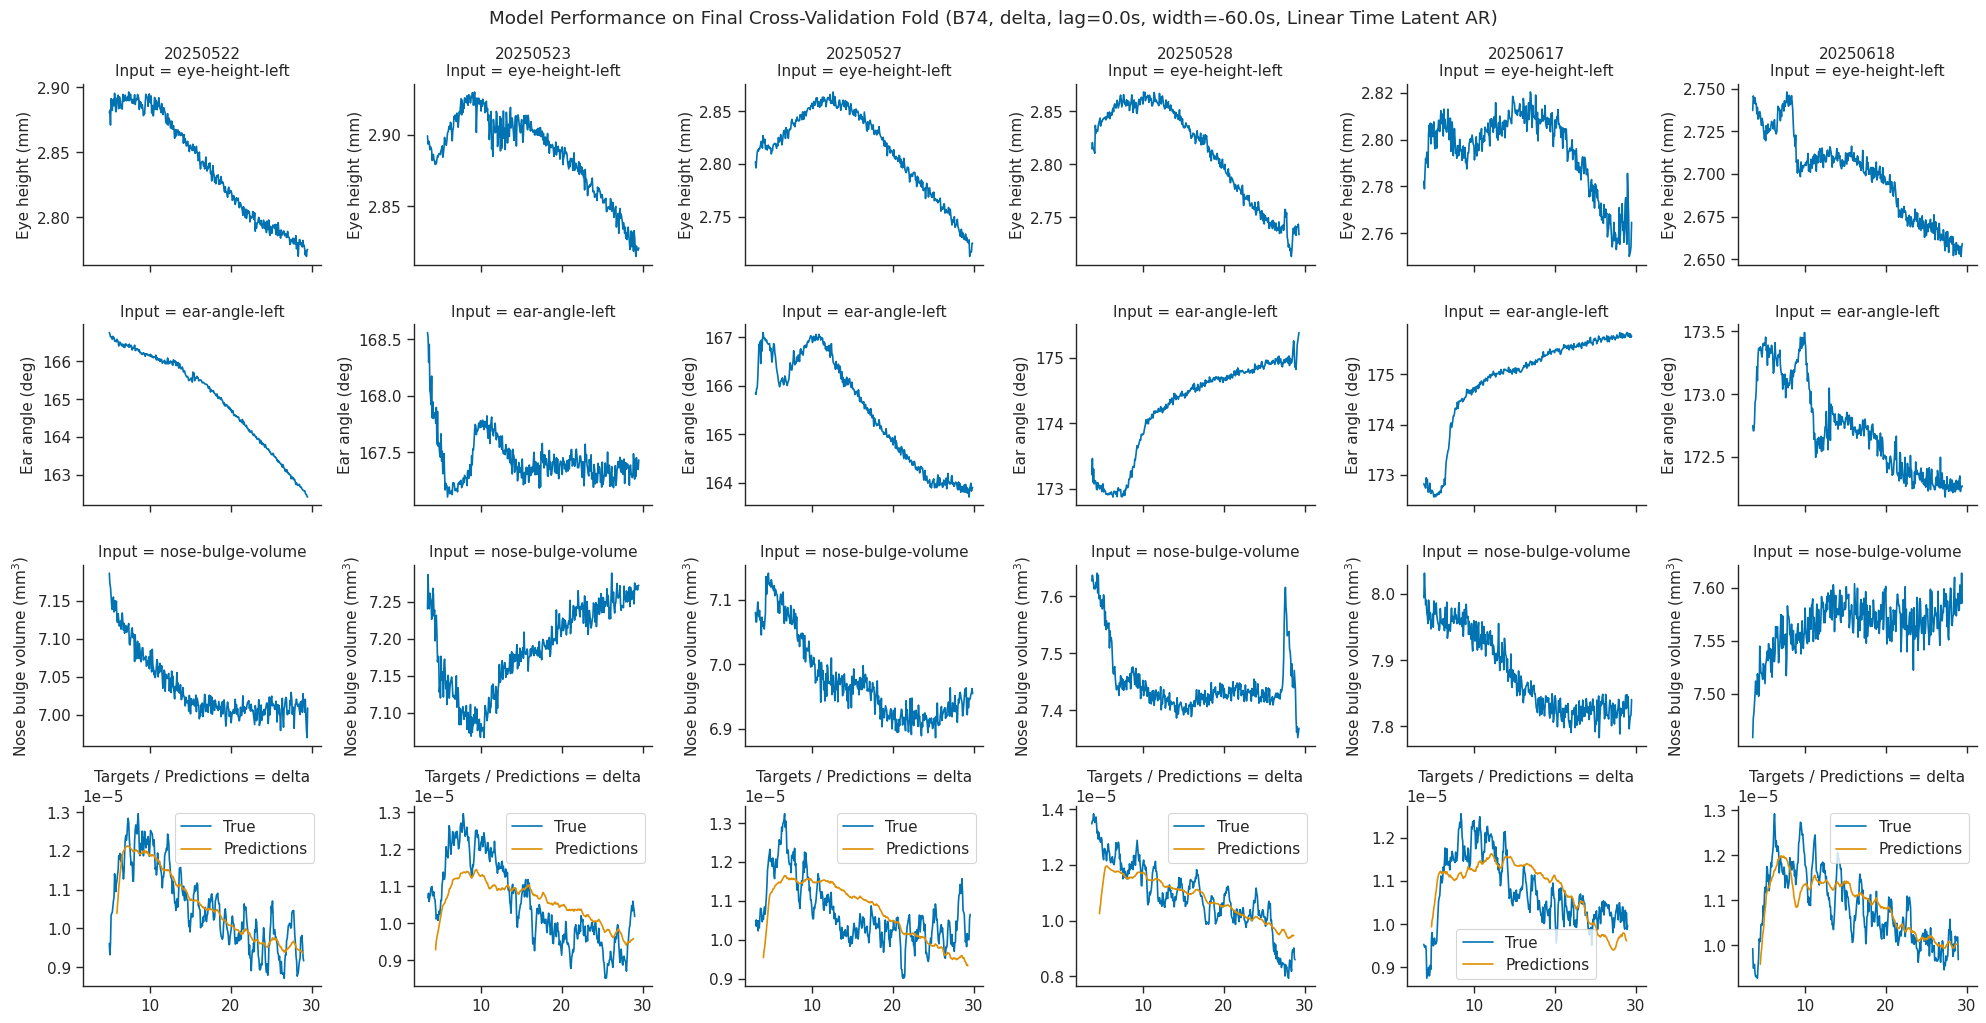

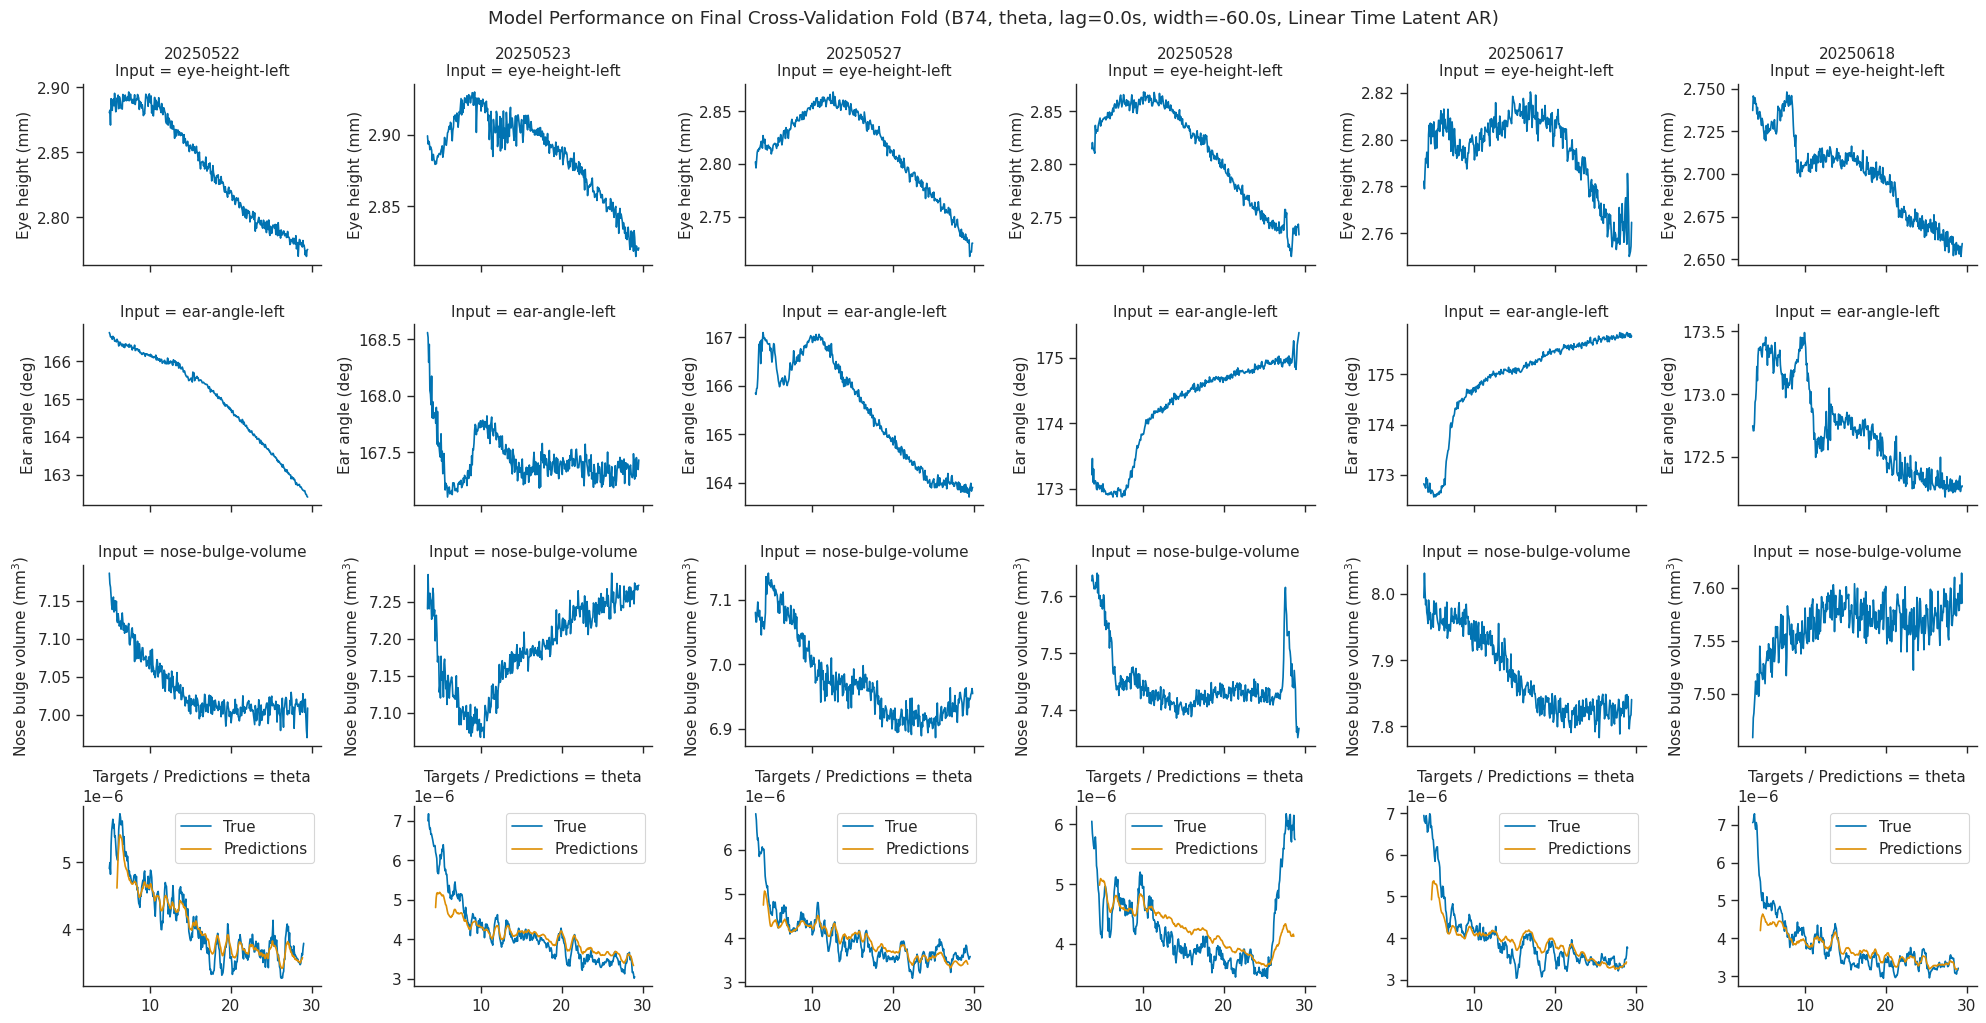

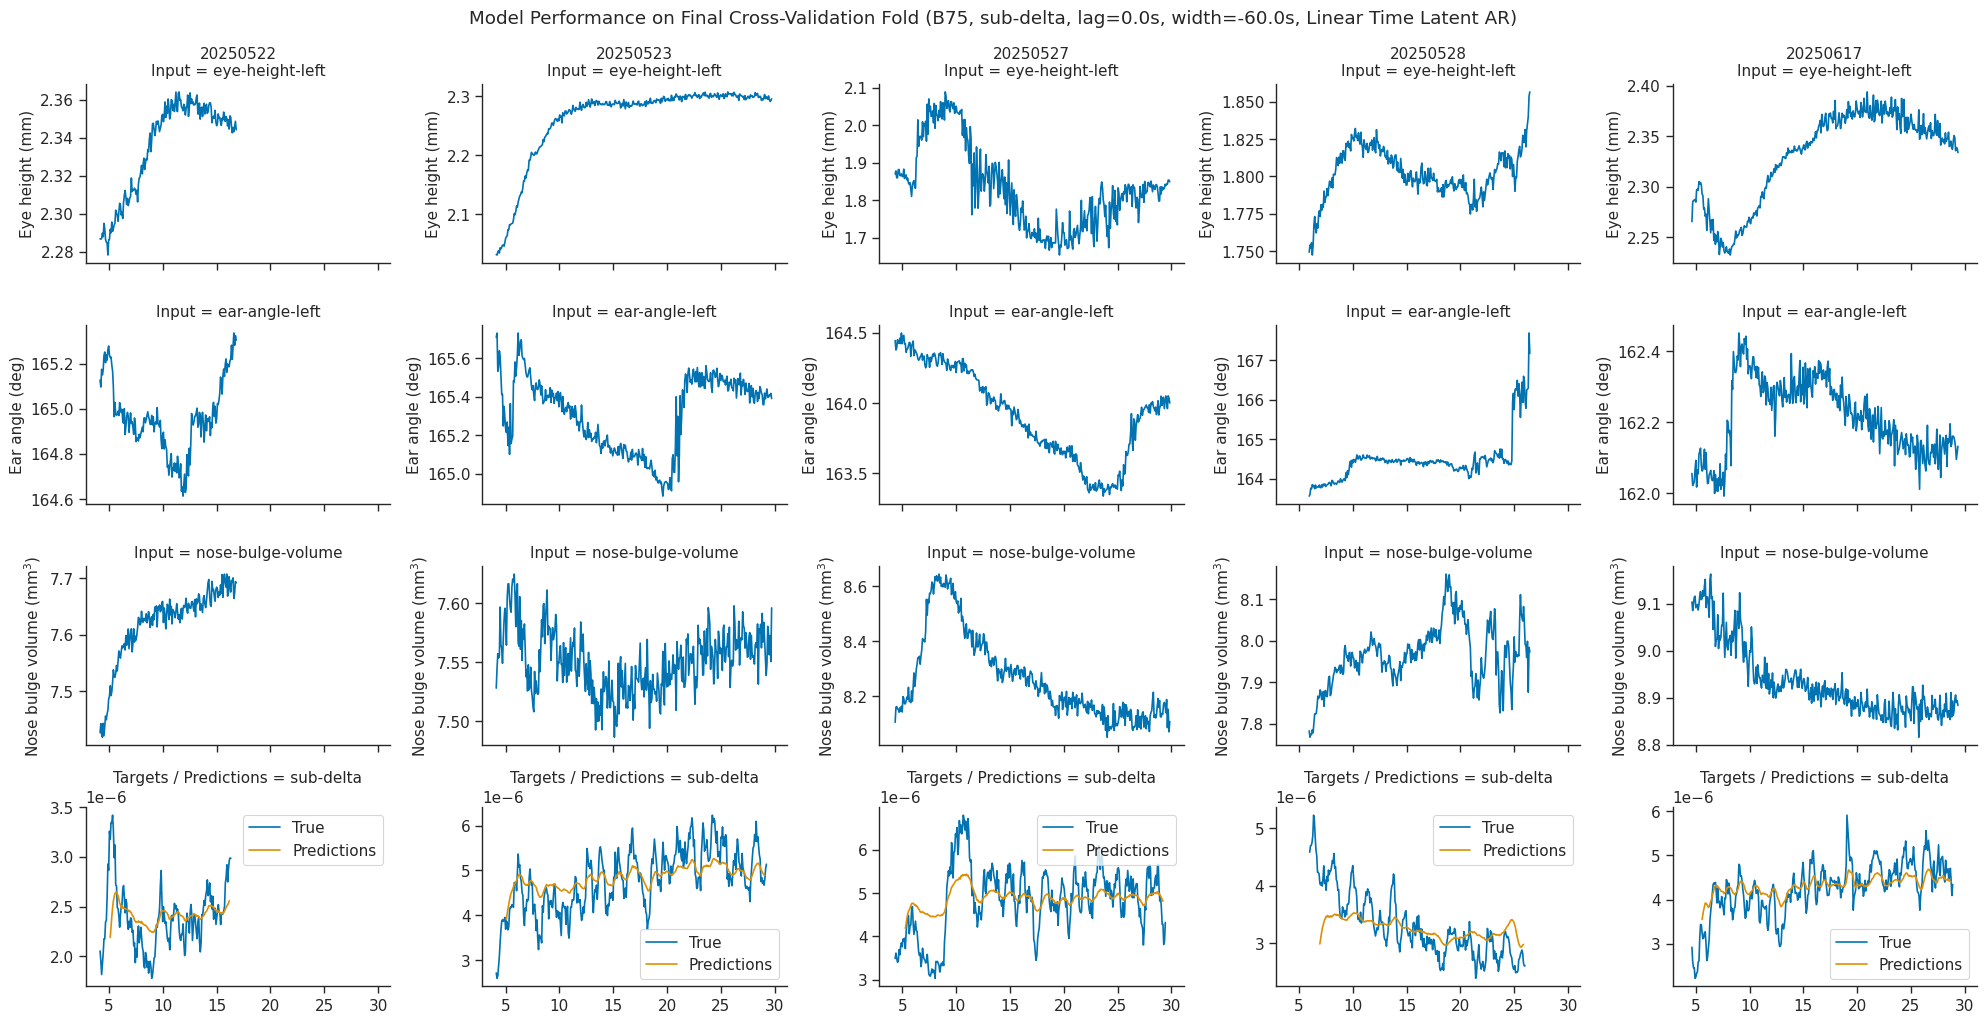

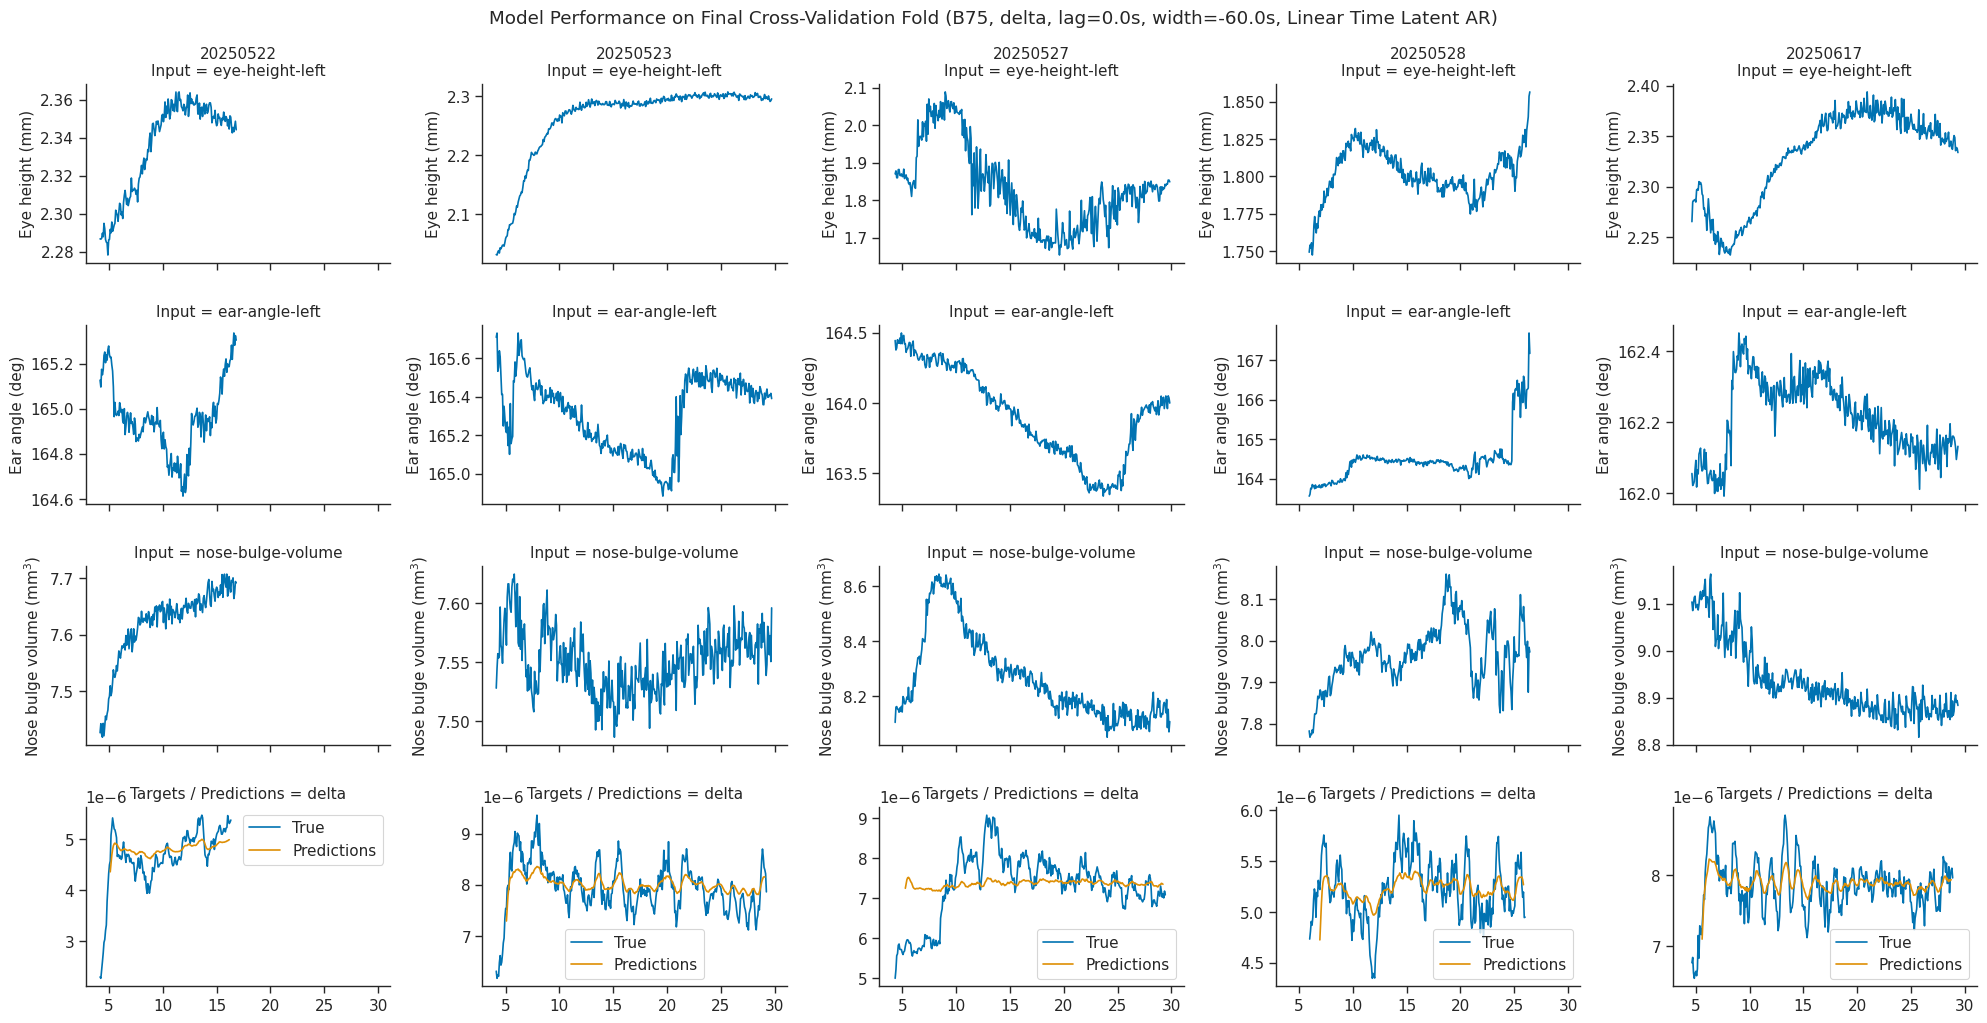

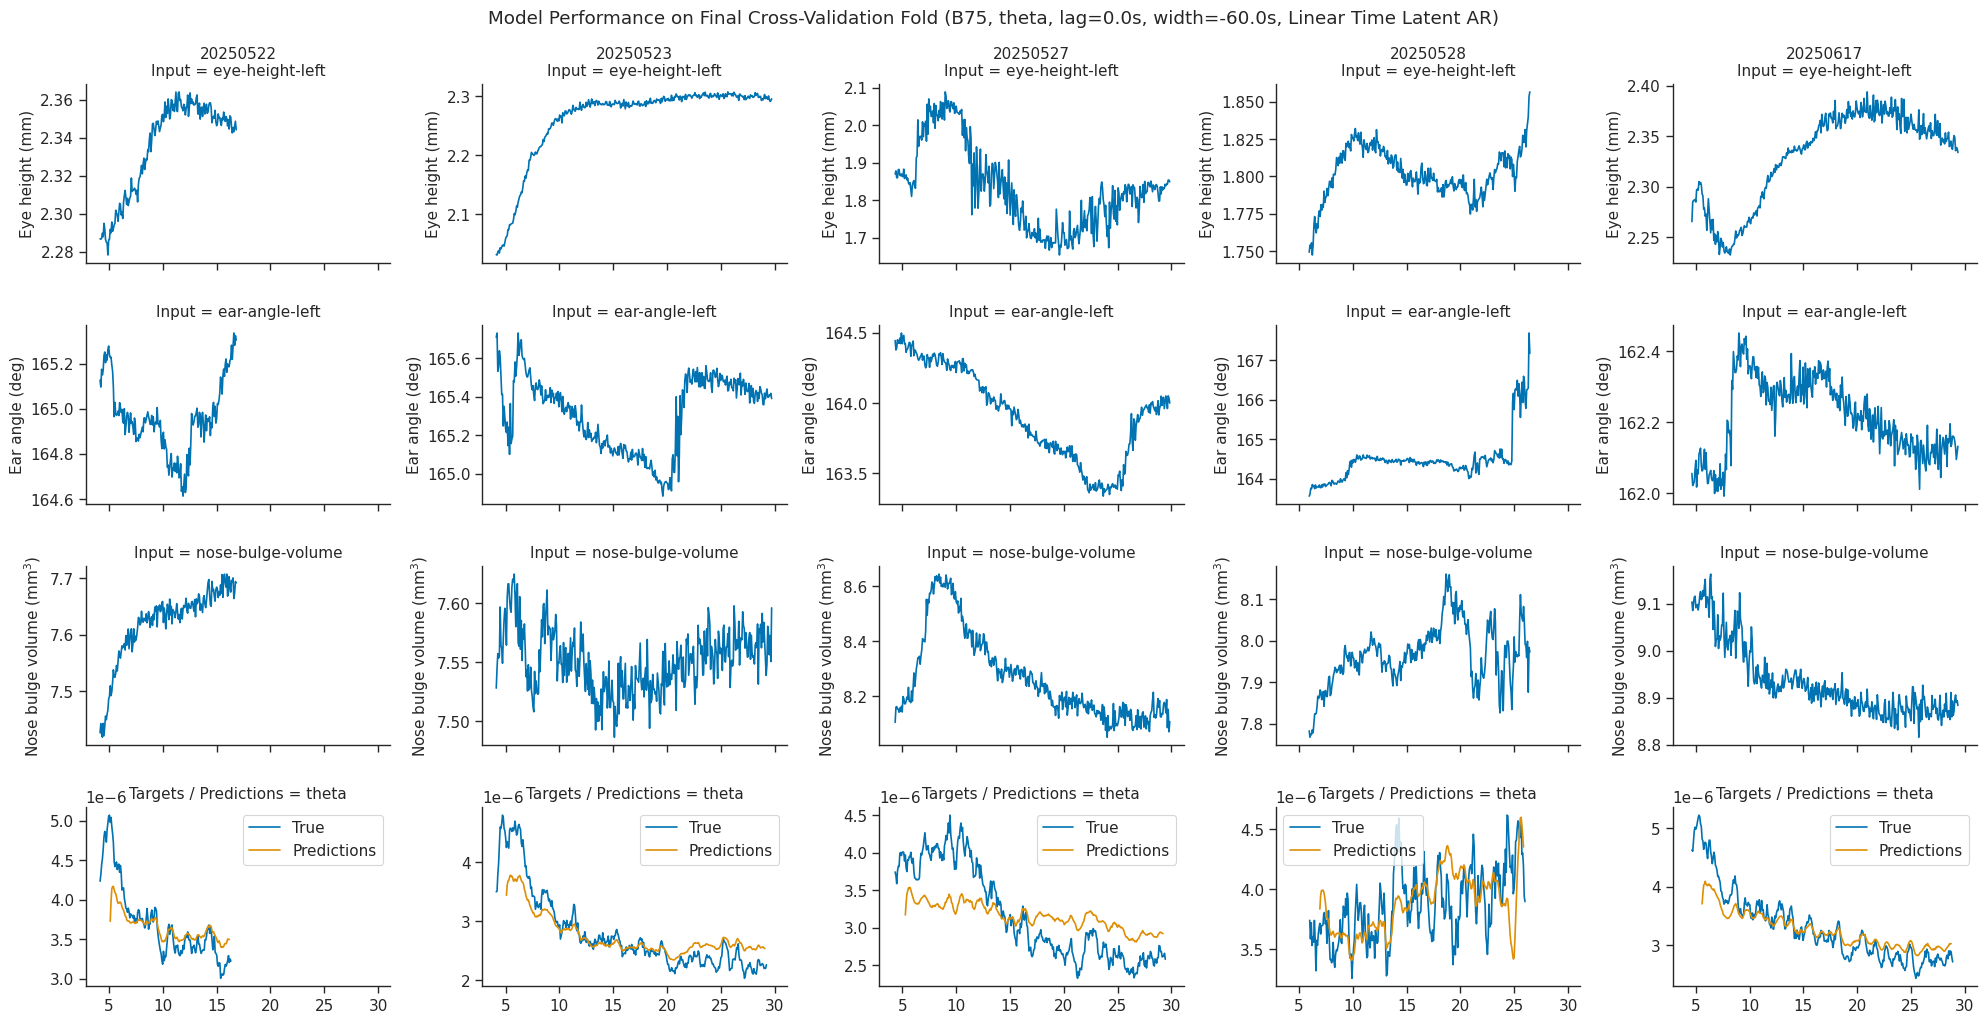

In [22]:
fe_power_pairs = {}
stat_variant = (0.0, -60.0)
plot_df = prediction_stats_df.query("measurement_group != 'c3d_3_to_time' & " \
                                    "measurement_group.str.startswith('c3d_3_to_') & " \
                                    "stat_variant == @stat_variant & " \
                                    "stat_group == 'time_latent_reg'")
sessions = plot_df["session"].unique()
unit_pairs = plot_df["measurement_group"].unique()
for session in sessions:
    for unit_pair in unit_pairs:
        mask = (plot_df["session"] == session) & \
               (plot_df["measurement_group"] == unit_pair)
        if mask.sum() == 0:
            continue
        deviance_explained = plot_df.loc[mask, "stat_value"].values
        max_deviance = max(np.mean(np.clip(r, 0, None)) for r in deviance_explained)
        if max_deviance > min_var_explained:
            if session not in fe_power_pairs:
                fe_power_pairs[session] = []
            fe_power_pairs[session].append(unit_pair)

measurement_order = [
    "eye-height-left",
    "ear-angle-left",
    "nose-bulge-volume"
]

for (mouse,), unit_pairs in fe_power_pairs.items():
    for unit_pair in unit_pairs:
        measurement_name, band_name = unit_pair.split("_to_")
        # Query prediction_stats_df for the specific unit pairs
        df = plot_df.query("mouse == @mouse & " \
                           "measurement_group == @unit_pair")
        deviance = np.array([np.mean(np.clip(np.nan_to_num(r, nan=0), 0, None))
                             for r in df["stat_value"].values])
        max_lag = np.argmax(deviance)
        lag, width = df["stat_variant"].values[max_lag]
        path = glob(str(MODEL_CACHE / "c3d_3" / "power_bands" / band_name / f"{mouse}_{lag}_{width}" / "time_latent_reg"))
        if len(path) == 1:
            path = Path(path[0])
        else:
            print(f"Skipping {mouse}, {unit_pair} - multiple or no paths found")
            continue
        # Load predictions
        if (path / "test_indices.npy").exists():
            test_indices = np.load(path / "test_indices.npy")
            predictions = [np.load(path / f"fold_{i}" / "predictions.npy")
                           for i in range(len(test_indices))]
        else:
            print(f"Skipping {mouse}, {unit_pair} - no predictions found")
            continue
        # Load input / targets
        features = merge_df.query(
            "mouse == @mouse & " \
            "(measurement_name == 'eye-height-left' | " \
            " measurement_name == 'ear-angle-left' | " \
            " measurement_name == 'nose-bulge-volume')"
        ).assign(measurement_name=lambda df: pd.Categorical(
            df["measurement_name"],
            categories=measurement_order, ordered=True
        )).sort_values("measurement_name")
        true = merge_df.query(
            "mouse == @mouse & " \
            f"measurement_type == '{band_name}-power' & " \
            "measurement_name == 'eeg-initial'"
        )
        features, true = align_by_session(features, true, group_by="date")
        features = resample_by_session(features, true, group_by="date")
        sample_rate = true["sample_rate"].values
        int_lag = (lag * sample_rate).astype(int)
        int_sw_window = (width * sample_rate).astype(int)
        int_ar_window = (ar_window_width * sample_rate).astype(int)
        dates = true["date"].values
        feature_ts = get_timeseries_matrix(features, column="domain", group_by="measurement_name")[:, :, 0]
        true_ts = get_timeseries_matrix(true, column="domain")
        features = get_timeseries_matrix(features, group_by="measurement_name")
        true = get_timeseries_matrix(true)
        nsessions = features.shape[0]

        # Create plot
        fig, axs = plt.subplots(4, nsessions, figsize=(20, 10), sharex=True)
        for i in range(nsessions):
            # Find test fold
            test_idx = np.where(test_indices == i)[0]
            # Plot features
            sns.lineplot(x=feature_ts[i] / 60, y=features[i, :, 0], ax=axs[0, i])
            axs[0, i].set_title(f"{dates[i]}\nInput = eye-height-left")
            axs[0, i].set_ylabel("Eye height (mm)")
            sns.lineplot(x=feature_ts[i] / 60, y=features[i, :, 1], ax=axs[1, i])
            axs[1, i].set_title(f"Input = ear-angle-left")
            axs[1, i].set_ylabel("Ear angle (deg)")
            sns.lineplot(x=feature_ts[i] / 60, y=features[i, :, 2], ax=axs[2, i])
            axs[2, i].set_title(f"Input = nose-bulge-volume")
            axs[2, i].set_ylabel("Nose bulge volume (mm$^3$)")
            # Plot targets / predictions
            preds = predictions[test_idx[0]][0]
            if int_lag[i] > 0:
                pred_ts = true_ts[i, :-int_lag[i]]
            else:
                pred_ts = true_ts[i, abs(int_lag[i]):]
            if int_sw_window[i] > 0:
                pred_ts = pred_ts[:-int_sw_window[i]]
            else:
                pred_ts = pred_ts[abs(int_sw_window[i]):]
            min_len = min(pred_ts.shape[0], preds.shape[0])
            pred_ts = pred_ts[:min_len]
            preds = preds[:min_len, 1]
            sns.lineplot(x=true_ts[i, :-(eeg_smooth_window - 1)] / 60,
                         y=moving_average(true[i], window_size=eeg_smooth_window),
                         label="True", ax=axs[3, i])
            sns.lineplot(x=pred_ts[:-(eeg_smooth_window - 1)] / 60,
                         y=moving_average(preds, window_size=eeg_smooth_window),
                         label="Predictions", ax=axs[3, i])
            axs[3, i].set_title(f"Targets / Predictions = {band_name}")
        plt.tight_layout()
        sns.despine(fig)
        plt.suptitle(f"Model Performance on Final Cross-Validation Fold ({mouse}, {band_name}, {lag=}s, {width=}s, Linear Time Latent AR)", y=1.02)
        output = Path(OUTPUT_DIR) / "c3d_3" / "power_bands" / band_name / f"{mouse}_{lag}_{width}" / "time_latent_reg"
        output.mkdir(parents=True, exist_ok=True)
        save_figure(str(output), "prediction_trace", fig, dpi=200)

### Panel I

,session,mouse,measurement_group,stat_variant,stat_group,stat_name,stat_value,stat_value_smooth,variance_explained
197,"(B47,)",B47,theta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[-0.4010415272535175, 0.394786171008075, 0.330...","[-1.6024918578712466, 0.7740679920387581, 0.77...",52.236867
206,"(B48,)",B48,theta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.12541607287370216, 0.32210018051076994, 0.3...","[0.4622438006652554, 0.7750818528957706, 0.738...",65.183319
215,"(B53,)",B53,theta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.1047257092701882, 0.22367615184976852, 0.20...","[0.6032494679005149, 0.6110005803841686, 0.387...",40.032772
224,"(B72,)",B72,theta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.5118692397265996, 0.3309398849351918, 0.352...","[0.9101466471725905, 0.8214678082249931, 0.784...",67.890437
242,"(B74,)",B74,theta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.2900836628702794, 0.35256435176238365, 0.28...","[0.9027850336509281, 0.7863479182177886, 0.793...",71.069121
251,"(B75,)",B75,theta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.47694889896891446, 0.31425383914665717, 0.2...","[0.7746038930876129, 0.7769094417342175, 0.405...",51.508901
196,"(B47,)",B47,delta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[-0.01110460674257796, 0.043792058396569855, -...","[0.34801197770918546, 0.16867129875273312, 0.3...",30.915730
205,"(B48,)",B48,delta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.05008742024244528, 0.10174327049964837, 0.1...","[0.5465176314587616, 0.4504888139390322, 0.421...",43.804985
214,"(B53,)",B53,delta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[0.3954296528852099, 0.25102557563431516, 0.28...","[0.81432848764168, 0.5765596934149197, 0.55849...",48.734553
223,"(B72,)",B72,delta,"(0.0, -60.0)",Time-Latent (AR),pearson_r,"[-0.04841436578634317, -0.11381589630555977, 0...","[0.5284947186922178, 0.3081405397091119, 0.693...",57.978563


,stat_group,measurement_group,mean,std,count
0,Linear (SW),theta,NaN,NaN,0
1,Linear (SW),delta,NaN,NaN,0
2,Linear (SW),sub-delta,NaN,NaN,0
3,Linear (AR),theta,NaN,NaN,0
4,Linear (AR),delta,NaN,NaN,0
5,Linear (AR),sub-delta,NaN,NaN,0
6,Linear (VAR),theta,NaN,NaN,0
7,Linear (VAR),delta,NaN,NaN,0
8,Linear (VAR),sub-delta,NaN,NaN,0
9,Time-Latent (AR),theta,57.986903,11.986585,6


/tmp/ipykernel_174277/3058676921.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=plot_df, x="measurement_group", y="variance_explained",
/tmp/ipykernel_174277/3058676921.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x="measurement_group", y="variance_explained",


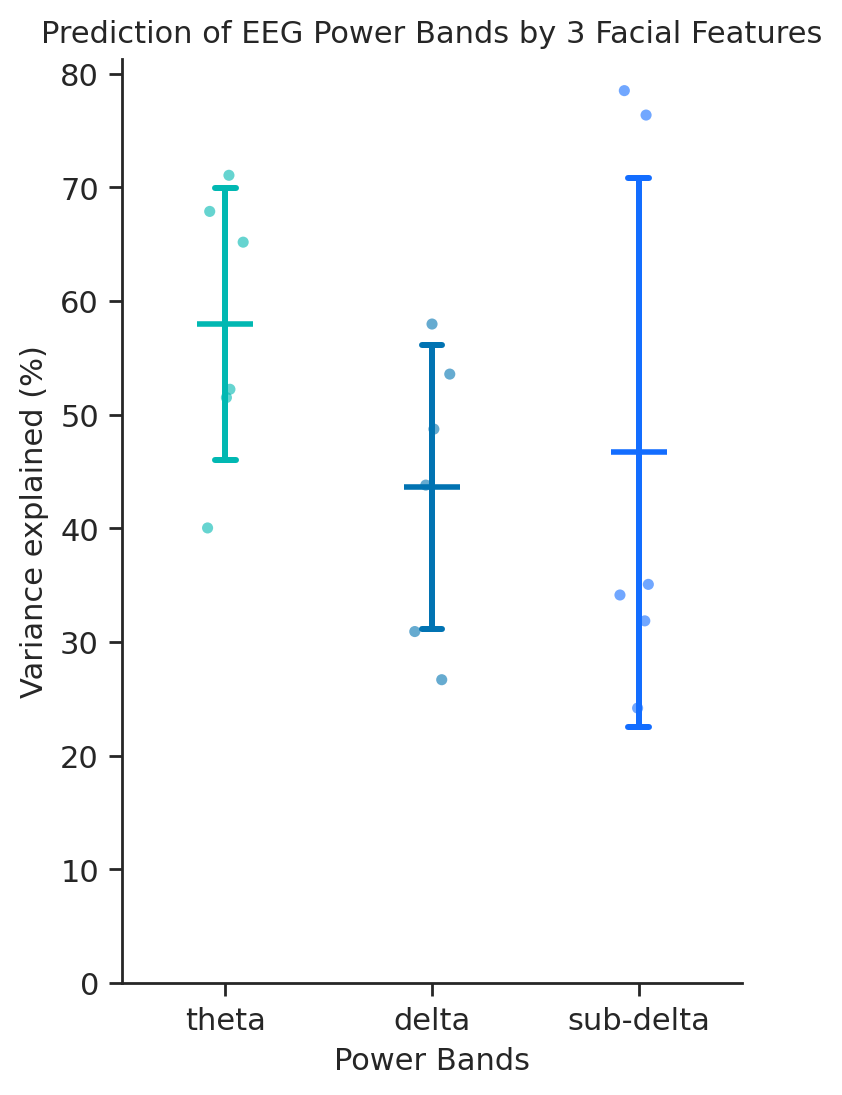

In [23]:
variant = (0.0, -60.0)
plot_df = prediction_stats_df.query(
    "measurement_group.str.startswith('c3d_3_') & " \
    "~measurement_group.str.endswith('_time') & " \
    "stat_group.str.contains('time_latent_reg') & " \
    "stat_variant == @variant & " \
    "mouse != 'B73'"
).copy()
plot_df["measurement_group"] = plot_df["measurement_group"].str.replace("c3d_3_to_", "", regex=False)
plot_df["stat_group"] = plot_df["stat_group"].replace({
    "linear_reg_sw": "Linear (SW)",
    "linear_reg_ar": "Linear (AR)",
    "linear_reg_var": "Linear (VAR)",
    "time_latent_reg": "Time-Latent (AR)",
    "random_forest_sw": "Random Forest (SW)",
    "random_forest_ar": "Random Forest (AR)",
    "random_forest_var": "Random Forest (VAR)",
    "lds": "Linear Dynamical System"
})

def summarize_stat(v):
    arr = np.asarray(v)
    arr = np.nan_to_num(arr, nan=0.0)
    arr = np.clip(arr, 0, None)
    return arr.mean() * 100  # percent variance explained
plot_df["variance_explained"] = plot_df["stat_value_smooth"].apply(summarize_stat)

stat_group_order = ["Linear (SW)", "Linear (AR)", "Linear (VAR)", "Time-Latent (AR)"]
# stat_group_order = ["Time-Latent (AR)"]
measurement_group_order = ["theta", "delta", "sub-delta"]
plot_df["stat_group"] = pd.Categorical(plot_df["stat_group"], categories=stat_group_order, ordered=True)
plot_df["measurement_group"] = pd.Categorical(plot_df["measurement_group"], categories=measurement_group_order, ordered=True)
plot_df = plot_df.sort_values(["stat_group", "measurement_group"])
display(plot_df)

summary_df = (plot_df
              .groupby(["stat_group", "measurement_group"], observed=False)["variance_explained"]
              .agg(["mean", partial(pd.Series.std, ddof=1), "count"])
              .reset_index())
display(summary_df)

fig, ax = plt.subplots(figsize=(4, 6), dpi=200)
hue_colors = ["#01b8b2", "#0173b2", "#136dff"]
sns.pointplot(data=plot_df, x="measurement_group", y="variance_explained",
              order=measurement_group_order,
              palette=hue_colors,
              errorbar=lambda x: (np.mean(x) - np.std(x, ddof=1), np.mean(x) + np.std(x, ddof=1)),
              linestyles="none",
              capsize=0.1,
              markersize=20,
              markeredgewidth=2,
              markers="_")
sns.stripplot(data=plot_df, x="measurement_group", y="variance_explained",
              order=measurement_group_order,
              palette=hue_colors,
              alpha=0.6,
              size=4,
              legend=False,
              ax=ax)
ax.set_xlabel("Power Bands")
ax.set_ylabel("Variance explained (%)")
ax.set_ylim(0, None)
ax.set_title("Prediction of EEG Power Bands by 3 Facial Features")
sns.despine(fig)
save_figure(OUTPUT_DIR, "cd3_3_to_power_bands_variance_explained_time_latent_smooth", fig, dpi=200)